# Setup

In [20]:
# SETUP CELL

import os
import h5py
import torch

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CLONE ORIGINAL GITHUB REPO INTO DRIVE

%cd '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code'
!git clone https://github.com/john-hewitt/structural-probes.git
%cd structural-probes

/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code
Cloning into 'structural-probes'...
remote: Enumerating objects: 261, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 261 (delta 0), reused 0 (delta 0), pack-reused 260 (from 2)
Receiving objects: 100% (261/261), 599.30 KiB | 4.57 MiB/s, done.
Resolving deltas: 100% (193/193), done.
/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes


In [21]:
# INSTALLING REQUIREMENTS

# PyTorch is pre-installed in Colab - verify it
import torch

# Install packages from requirements.txt
!pip install scipy numpy h5py seaborn PyYAML tqdm Cython

# Install pytorch-pretrained-bert as specified in the README
!pip install pytorch-pretrained-bert

# Verify key imports work
import scipy
import numpy
import h5py
import yaml
import tqdm
print("All packages imported successfully")

All packages imported successfully


In [ ]:
# (OPTIONAL) DELETE UNNECESSARY .HDF5 FILES STORED LOCALLY

!rm /content/embeddings/*.hdf5

# English (UD-EWT)


## 1. Data Preparation

In [ ]:
# CLONE ENGLISH UD-EWT TREEBANK

import os

# Define your base project path - replace with your actual folder path
base = '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/'

# Create folder structure for English only
os.makedirs(f'{base}/data/en', exist_ok=True)
os.makedirs(f'{base}/results/en', exist_ok=True)
os.makedirs(f'{base}/models', exist_ok=True)

# Clone English treebank only
%cd {base}/data/en
!git clone https://github.com/UniversalDependencies/UD_English-EWT.git

print("English folder structure and treebank ready")

/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/en
Cloning into 'UD_English-EWT'...
remote: Enumerating objects: 49423, done.
remote: Counting objects: 100% (957/957), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 49423 (delta 910), reused 871 (delta 846), pack-reused 48466 (from 2)
Receiving objects: 100% (49423/49423), 403.46 MiB | 26.58 MiB/s, done.
Resolving deltas: 100% (44241/44241), done.
Updating files: 100% (1202/1202), done.
English folder structure and treebank ready


In [ ]:
# SANITY CHECKS

# Sanity Check 1: PyTorch and GPU
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU device: NVIDIA A100-SXM4-40GB


In [ ]:
# Sanity Check 2: Imports
import scipy
import numpy as np
import h5py
import yaml
import tqdm
import seaborn
import matplotlib
from pytorch_pretrained_bert import BertTokenizer, BertModel
print("scipy:", scipy.__version__)
print("numpy:", np.__version__)
print("h5py:", h5py.__version__)
print("All imports successful")

scipy: 1.16.3
numpy: 2.0.2
h5py: 3.15.1
All imports successful


In [ ]:
# Sanity Check 3: Treebank Data
# Point this at one of your downloaded conllu files
conllu_path = '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/en/UD_English-EWT/en_ewt-ud-train.conllu'

sentence_count = 0
token_count = 0
with open(conllu_path) as f:
    for line in f:
        if line.startswith('#'):
            continue
        if not line.strip():
            sentence_count += 1
        else:
            token_count += 1

print(f"Sentences: {sentence_count}")
print(f"Tokens: {token_count}")

Sentences: 12544
Tokens: 207228


In [ ]:
# Sanity Check 4: BERT Loading and Inference
from pytorch_pretrained_bert import BertTokenizer, BertModel
import torch

# Load BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')
model = BertModel.from_pretrained('bert-base-cased')
model.eval()
model.to('cuda' if torch.cuda.is_available() else 'cpu')

# Run a test sentence
test_sentence = "The cat sat on the mat ."
tokenized = tokenizer.wordpiece_tokenizer.tokenize('[CLS] ' + test_sentence + ' [SEP]')
indexed = tokenizer.convert_tokens_to_ids(tokenized)
tokens_tensor = torch.tensor([indexed]).to('cuda' if torch.cuda.is_available() else 'cpu')
segments_tensor = torch.tensor([[1] * len(indexed)]).to('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    encoded_layers, _ = model(tokens_tensor, segments_tensor)

print(f"Number of layers: {len(encoded_layers)}")
print(f"Sequence length: {encoded_layers[0].shape[1]}")
print(f"Hidden dimension: {encoded_layers[0].shape[2]}")
print("BERT inference successful")

"""
Expected output:

Number of layers: 12
Sequence length: 10
Hidden dimension: 768
BERT inference successful
"""

100%|██████████| 404400730/404400730 [00:08<00:00, 48906803.58B/s]


Number of layers: 12
Sequence length: 9
Hidden dimension: 768
BERT inference successful


'\nExpected output:\n\nNumber of layers: 12\nSequence length: 10\nHidden dimension: 768\nBERT inference successful\n'

In [ ]:
# Sanity Check 5: HDF5 Writing and Reading
import h5py
import numpy as np

test_path = '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/test_embeddings.hdf5'

# Write a test HDF5 file
with h5py.File(test_path, 'w') as f:
    # Simulate one sentence: 12 layers, 5 words, 768 dimensions
    fake_embeddings = np.random.randn(12, 5, 768)
    f.create_dataset('0', data=fake_embeddings)

# Read it back
with h5py.File(test_path, 'r') as f:
    loaded = f['0'][:]
    print(f"Shape: {loaded.shape}")
    print(f"Expected: (12, 5, 768)")
    print(f"Match: {loaded.shape == (12, 5, 768)}")

# Clean up
import os
os.remove(test_path)
print("HDF5 read/write successful")

"""
Expected output:

Shape: (12, 5, 768)
Expected: (12, 5, 768)
Match: True
HDF5 read/write successful
"""

Shape: (12, 5, 768)
Expected: (12, 5, 768)
Match: True
HDF5 read/write successful


'\nExpected output:\n\nShape: (12, 5, 768)\nExpected: (12, 5, 768)\nMatch: True\nHDF5 read/write successful\n'

In [ ]:
# Sanity Check 6: Structural Probes Codebase

import sys
sys.path.insert(0, '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes')

import data
import model
import probe
import task
import loss

# Test probe instantiation with minimal args
args = {
    'probe': {
        'maximum_rank': 128,
        'task_name': 'parse-distance',
        'task_signature': 'word_pair',
        'psd_parameters': True,
        'params_path': 'test.params'
    },
    'model': {
        'hidden_dim': 768
    },
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'reporting': {
        'root': '/content/'
    }
}

distance_probe = probe.TwoWordPSDProbe(args)
depth_probe = probe.OneWordPSDProbe(args)
print(f"Distance probe parameter shape: {distance_probe.proj.shape}")
print(f"Depth probe parameter shape: {depth_probe.proj.shape}")
print("Probe instantiation successful")

"""
Expected output:

Constructing TwoWordPSDProbe
Constructing OneWordPSDProbe
Distance probe parameter shape: torch.Size([768, 128])
Depth probe parameter shape: torch.Size([768, 128])
Probe instantiation successful
"""

Constructing TwoWordPSDProbe
Constructing OneWordPSDProbe
Distance probe parameter shape: torch.Size([768, 128])
Depth probe parameter shape: torch.Size([768, 128])
Probe instantiation successful


'\nExpected output:\n\nConstructing TwoWordPSDProbe\nConstructing OneWordPSDProbe\nDistance probe parameter shape: torch.Size([768, 128])\nDepth probe parameter shape: torch.Size([768, 128])\nProbe instantiation successful\n'

## 2. BERT Extraction

In [ ]:
# CONVERT CONLL-U FILES TO RAW TEXT FILES

# Convert train split

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" \
  "$BASE/data/en/UD_English-EWT/en_ewt-ud-train.conllu" \
  > "$BASE/data/en/UD_English-EWT/en_ewt-ud-train.txt"

In [ ]:
# Convert dev split

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" \
  "$BASE/data/en/UD_English-EWT/en_ewt-ud-dev.conllu" \
  > "$BASE/data/en/UD_English-EWT/en_ewt-ud-dev.txt"

In [ ]:
# Convert test split

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" \
  "$BASE/data/en/UD_English-EWT/en_ewt-ud-test.conllu" \
  > "$BASE/data/en/UD_English-EWT/en_ewt-ud-test.txt"

In [ ]:
# Sanity Check - All splits

!wc -l "$BASE/data/en/UD_English-EWT/en_ewt-ud-train.txt"
!wc -l "$BASE/data/en/UD_English-EWT/en_ewt-ud-dev.txt"
!wc -l "$BASE/data/en/UD_English-EWT/en_ewt-ud-test.txt"
!head -3 "$BASE/data/en/UD_English-EWT/en_ewt-ud-train.txt"

12544 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/en/UD_English-EWT/en_ewt-ud-train.txt
2001 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/en/UD_English-EWT/en_ewt-ud-dev.txt
2077 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/en/UD_English-EWT/en_ewt-ud-test.txt
Al - Zaman : American forces killed Shaikh Abdullah al - Ani , the preacher at the mosque in the town of Qaim , near the Syrian border .
[ This killing of a respected cleric will be causing us trouble for years to come . ]
DPA : Iraqi authorities announced that they had busted up 3 terrorist cells operating in Baghdad .


In [ ]:
# TRUNCATE ENGLISH CONLL-U FILE TO 11,000 SENTENCES
# This is for consistency across languages within a treebank range of 9,000 to 11,000 sentences.

def truncate_conllu(input_path, output_path, max_sents):
    sentences_written = 0
    current_sentence = []

    with open(input_path, 'r') as fin, open(output_path, 'w') as fout:
        for line in fin:
            if line.strip() == '':
                if current_sentence:
                    fout.write(''.join(current_sentence) + '\n')
                    sentences_written += 1
                    current_sentence = []
                    if sentences_written == max_sents:
                        break
            else:
                current_sentence.append(line)

    print(f"Written {sentences_written} sentences to {output_path}")

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

truncate_conllu(
    f"{BASE}/data/en/UD_English-EWT/en_ewt-ud-train.conllu",
    f"{BASE}/data/en/UD_English-EWT/en_ewt-ud-train-11k.conllu",
    11000
)

Written 11000 sentences to /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/en/UD_English-EWT/en_ewt-ud-train-11k.conllu


In [ ]:
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" \
"$BASE/data/en/UD_English-EWT/en_ewt-ud-train-11k.conllu" \
> "$BASE/data/en/UD_English-EWT/en_ewt-ud-train-11k.txt"

In [ ]:
# EXTRACT BERT EMBEDDINGS TO HDF5 FILES (TRAIN SPLIT)

!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" \
"$BASE/data/en/UD_English-EWT/en_ewt-ud-train-11k.txt" \
"$BASE/data/en/UD_English-EWT/en_ewt-ud-train-11k.hdf5" base

The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.


In [ ]:
# EXTRACT BERT EMBEDDINGS TO HDF5 FILES (DEV & TEST SPLITS)

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/en/UD_English-EWT/en_ewt-ud-dev.txt" "$BASE/data/en/UD_English-EWT/en_ewt-ud-dev.hdf5" base

!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/en/UD_English-EWT/en_ewt-ud-test.txt" "$BASE/data/en/UD_English-EWT/en_ewt-ud-test.hdf5" base

The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.


In [ ]:
import os
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
path = f"{BASE}/data/en/UD_English-EWT/en_ewt-ud-train-11k.hdf5"
print(os.path.exists(path))
print(os.path.getsize(path) / 1e9, "GB")

True
8.57650768 GB


In [ ]:
# SANITY CHECK - HDF5 File Retrieval
# Takes a while to run...

import h5py

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
splits = ['train', 'dev', 'test']
expected_counts = [12544, 2001, 2077]

for split, expected in zip(splits, expected_counts):
  path = f"{BASE}/data/en/UD_English-EWT/en_ewt-ud-{split}.hdf5"
  with h5py.File(path, 'r') as f:
    count = len(f.keys())
    shape = f['0'].shape
    print(f"{split}: {count} sentences (expected {expected}), first sentence shape: {shape}")

In [ ]:
from pytorch_pretrained_bert import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')
print("Tokenizer cached successfully!")

100%|██████████| 213450/213450 [00:00<00:00, 331179.24B/s]

Tokenizer cached successfully!


In [ ]:
!ls ~/.pytorch_pretrained_bert/

5e8a2b4893d13790ed4150ca1906be5f7a03d6c4ddf62296c383f6db42814db2.e13dbb970cb325137104fb2e5f36fe865f27746c6b526f6352861b1980eb80b1
5e8a2b4893d13790ed4150ca1906be5f7a03d6c4ddf62296c383f6db42814db2.e13dbb970cb325137104fb2e5f36fe865f27746c6b526f6352861b1980eb80b1.json


In [ ]:
# REMOVE OLD LOCAL HDF5 FILES (OPTIONAL)

import os
os.remove("/content/embeddings/en_ewt-ud-train-11k.hdf5")
os.remove("/content/embeddings/en_ewt-ud-dev.hdf5")
os.remove("/content/embeddings/en_ewt-ud-test.hdf5")
print("Deleted!")

Deleted!


In [ ]:
# LOCALIZE HDF5 FILES

import shutil
import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
LOCAL = "/content/embeddings"
os.makedirs(LOCAL, exist_ok=True)

print("Copying train...")
shutil.copy(f"{BASE}/data/en/UD_English-EWT/en_ewt-ud-train-11k.hdf5", f"{LOCAL}/en_ewt-ud-train-11k.hdf5")
print("Copying dev...")
shutil.copy(f"{BASE}/data/en/UD_English-EWT/en_ewt-ud-dev.hdf5", f"{LOCAL}/en_ewt-ud-dev.hdf5")
print("Copying test...")
shutil.copy(f"{BASE}/data/en/UD_English-EWT/en_ewt-ud-test.hdf5", f"{LOCAL}/en_ewt-ud-test.hdf5")
print("Done!")

Copying train...
Copying dev...
Copying test...
Done!


## 3. Training & Evaluation


### Distance Probe

In [ ]:
import h5py
from pytorch_pretrained_bert import BertTokenizer

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
LOCAL = "/content/embeddings"
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

for split, n in [('train-11k', 11000), ('dev', 2001), ('test', 2077)]:
    mismatches = 0
    with h5py.File(f"{LOCAL}/en_ewt-ud-{split}.hdf5", 'r') as f:
        with open(f"{BASE}/data/en/UD_English-EWT/en_ewt-ud-{split}.txt") as txt:
            for i, line in enumerate(txt):
                hdf5_length = f[str(i)].shape[1]
                line = line.strip()
                tokenized = ['[CLS]']
                for word in line.split(' '):
                    tokenized += tokenizer.wordpiece_tokenizer.tokenize(word)
                tokenized += ['[SEP]']
                if hdf5_length != len(tokenized):
                    mismatches += 1
    print(f"{split}: {mismatches} mismatches")

train-11k: 0 mismatches
dev: 0 mismatches
test: 0 mismatches


In [ ]:
import h5py
from pytorch_pretrained_bert import BertTokenizer

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
LOCAL = "/content/embeddings"
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

with h5py.File(f"{LOCAL}/en_ewt-ud-train-11k.hdf5", 'r') as f:
    with open(f"{BASE}/data/en/UD_English-EWT/en_ewt-ud-train-11k.txt") as txt:
        for i, line in enumerate(txt):
            hdf5_length = f[str(i)].shape[1]
            line = line.strip()
            tokenized = ['[CLS]']
            for word in line.split(' '):
                tokenized += tokenizer.wordpiece_tokenizer.tokenize(word)
            tokenized += ['[SEP]']
            if hdf5_length != len(tokenized):
                print(f"MISMATCH at sentence {i}:")
                print(f"  HDF5 length: {hdf5_length}")
                print(f"  Tokenizer length: {len(tokenized)}")
                print(f"  Raw text: {line[:150]}")
                break

print("All done!")

All done!


In [ ]:
import h5py
from pytorch_pretrained_bert import BertTokenizer

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
LOCAL = "/content/embeddings"
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

# Read CoNLL-U sentences
conllu_sents = []
current = []
with open(f"{BASE}/data/en/UD_English-EWT/en_ewt-ud-train-11k.conllu") as f:
    for line in f:
        if line.startswith('#') or '-' in line.split('\t')[0] or '.' in line.split('\t')[0]:
            continue
        if line.strip() == '':
            if current:
                conllu_sents.append(current)
                current = []
        else:
            current.append(line.split('\t')[1])

with h5py.File(f"{LOCAL}/en_ewt-ud-train-11k.hdf5", 'r') as f:
    for i, sent in enumerate(conllu_sents):
        hdf5_length = f[str(i)].shape[1]
        tokenized = ['[CLS]']
        for word in sent:
            tokenized += tokenizer.wordpiece_tokenizer.tokenize(word)
        tokenized += ['[SEP]']
        if hdf5_length != len(tokenized):
            print(f"MISMATCH at sentence {i}:")
            print(f"  HDF5 length: {hdf5_length}")
            print(f"  Tokenizer length: {len(tokenized)}")
            print(f"  CoNLL-U tokens: {sent}")
            break
    else:
        print("No mismatches!")

No mismatches!


In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

# Get sentence 8 from raw text file
with open(f"{BASE}/data/en/UD_English-EWT/en_ewt-ud-train-11k.txt") as f:
    for i, line in enumerate(f):
        if i == 8:
            print("Raw text sentence 8:")
            print(repr(line))
            break

# Get sentence 8 from CoNLL-U file
sent_count = 0
current = []
with open(f"{BASE}/data/en/UD_English-EWT/en_ewt-ud-train-11k.conllu") as f:
    for line in f:
        if line.startswith('#') or '-' in line.split('\t')[0] or '.' in line.split('\t')[0]:
            continue
        if line.strip() == '':
            if current:
                if sent_count == 8:
                    print("CoNLL-U sentence 8 tokens:")
                    print(current)
                    break
                sent_count += 1
                current = []
        else:
            current.append(line.split('\t')[1])

Raw text sentence 8:
"Although the announcement was probably made to show progress in identifying and breaking up terror cells , I do n't find the news that the Baathists continue to penetrate the Iraqi government very hopeful .\n"
CoNLL-U sentence 8 tokens:
['Although', 'the', 'announcement', 'was', 'probably', 'made', 'to', 'show', 'progress', 'in', 'identifying', 'and', 'breaking', 'up', 'terror', 'cells', ',', 'I', 'do', "n't", 'find', 'the', 'news', 'that', 'the', 'Baathists', 'continue', 'to', 'penetrate', 'the', 'Iraqi', 'government', 'very', 'hopeful', '.']


In [ ]:
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/en-ewt-pad-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/en-ewt-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-15-39-28-606938/
Loading BERT Pretrained Embeddings from /content/embeddings/en_ewt-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/11000 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:429: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

dist_dir = "BERT-disk-parse-distance-2026-3-9-15-39-28-606938"

print("=== DISTANCE PROBE ===")
with open(f"{BASE}/results/en/en-ewt-pad-bert-base7/{dist_dir}/dev.uuas") as f:
    print("UUAS:", f.read().strip())
with open(f"{BASE}/results/en/en-ewt-pad-bert-base7/{dist_dir}/dev.spearmanr-5_50-mean") as f:
    print("DSpr.:", f.read().strip())

=== DISTANCE PROBE ===
UUAS: 0.785411999004232
DSpr.: 0.8104087000537025


### Depth Probe

In [ ]:
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/en-ewt-prd-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/en-ewt-prd-bert-base7/BERT-disk-parse-depth-2026-3-9-15-43-7-544735/
Loading BERT Pretrained Embeddings from /content/embeddings/en_ewt-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/11000 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:429: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

depth_dir = "BERT-disk-parse-depth-2026-3-9-15-43-7-544735"

print("\n=== DEPTH PROBE ===")
with open(f"{BASE}/results/en/en-ewt-prd-bert-base7/{depth_dir}/dev.root_acc") as f:
    print("Root%:", f.read().strip())
with open(f"{BASE}/results/en/en-ewt-prd-bert-base7/{depth_dir}/dev.spearmanr-5_50-mean") as f:
    print("NSpr.:", f.read().strip())


=== DEPTH PROBE ===
Root%: 0.8540729635182409	1709	2001
NSpr.: 0.8423881399020421


# French (UD-GSD)

## 1. Data Preparation

In [ ]:
# ACCESS FRENCH GSD TREEBANK

!git clone https://github.com/UniversalDependencies/UD_French-GSD "$BASE/data/fr/UD_French-GSD"

Cloning into '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/fr/UD_French-GSD'...
remote: Enumerating objects: 5336, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 5336 (delta 24), reused 26 (delta 13), pack-reused 5293 (from 2)
Receiving objects: 100% (5336/5336), 86.60 MiB | 15.88 MiB/s, done.
Resolving deltas: 100% (3889/3889), done.


In [ ]:
# Sanity Check

!ls "$BASE/data/fr/UD_French-GSD/"

CONTRIBUTING.md  fr_gsd-ud-dev.conllu	fr_gsd-ud-train.conllu	README.md
eval.log	 fr_gsd-ud-test.conllu	LICENSE.txt		stats.xml


In [ ]:
# CONLL-U TRUNCATION: 11K SENTENCES

def truncate_conllu(input_path, output_path, max_sents):
    sentences_written = 0
    current_sentence = []

    with open(input_path, 'r') as fin, open(output_path, 'w') as fout:
        for line in fin:
            if line.strip() == '':
                if current_sentence:
                    fout.write(''.join(current_sentence) + '\n')
                    sentences_written += 1
                    current_sentence = []
                    if sentences_written == max_sents:
                        break
            else:
                current_sentence.append(line)

    print(f"Written {sentences_written} sentences to {output_path}")

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

truncate_conllu(
    f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-train.conllu",
    f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.conllu",
    11000
)

Written 11000 sentences to /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.conllu


In [ ]:
# Sanity Check

!wc -l "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.conllu"

308646 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.conllu


In [ ]:
# CONVERT CONLL-U TO RAW

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.conllu" > "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-dev.conllu" > "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-dev.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-test.conllu" > "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-test.txt"

In [ ]:
# Sanity Check

!wc -l "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.txt"
!wc -l "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-dev.txt"
!wc -l "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-test.txt"
!head -2 "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.txt"

11000 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.txt
1476 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/fr/UD_French-GSD/fr_gsd-ud-dev.txt
416 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/fr/UD_French-GSD/fr_gsd-ud-test.txt
Les commotions cérébrales sont devenu si courantes dans ce sport qu' on les considére presque comme la routine .
L' œuvre est située dans la galerie de les batailles , dans le château de Versailles .


### Find sentences over 512 tokens

In [ ]:
# Find number of sentences

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
from pytorch_pretrained_bert import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

count = 0
with open(f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.txt") as f:
    for i, line in enumerate(f):
        tokens = tokenizer.wordpiece_tokenizer.tokenize('[CLS] ' + line.strip() + ' [SEP]')
        if len(tokens) > 512:
            count += 1
print(f"Sentences over 512 tokens: {count} out of 11000")

Sentences over 512 tokens: 0 out of 11000


In [ ]:
# Find exact sentences

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
from pytorch_pretrained_bert import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

with open(f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.txt") as f:
    for i, line in enumerate(f):
        tokens = tokenizer.wordpiece_tokenizer.tokenize('[CLS] ' + line.strip() + ' [SEP]')
        if len(tokens) > 512:
            print(f"Line {i}: {len(tokens)} tokens")
            print(line[:100])

Line 6443: 691 tokens
Le territoire très varié , les monuments de les villes , la gastronomie locale , dont les produits t


In [ ]:
# REMOVE 512+ TOKEN SENTENCES FROM FILES - FR

import re

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

# Remove sentence 6443 from txt file
with open(f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.txt") as f:
    lines = f.readlines()
del lines[6443]
with open(f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.txt", 'w') as f:
    f.writelines(lines)
print(f"txt now has {len(lines)} lines")

# Remove sentence 6443 from conllu file
with open(f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.conllu") as f:
    content = f.read()

sentences = content.strip().split('\n\n')
print(f"CoNLL had {len(sentences)} sentences")
del sentences[6443]
print(f"CoNLL now has {len(sentences)} sentences")

with open(f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.conllu", 'w') as f:
    f.write('\n\n'.join(sentences) + '\n\n')

txt now has 10999 lines
CoNLL had 11000 sentences
CoNLL now has 10999 sentences


## 2. BERT Extraction


In [ ]:
# BERT EXTRACTION - FR

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.txt" "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-dev.txt" "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-dev.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-test.txt" "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-test.hdf5" base

The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Token indices sequence length is longer than the specified maximum  sequence length for this BERT model (691 > 512). Running this sequence through BERT will result in indexing errors
/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [581,0,0], thread: [128,0,0] Assertion `ind >=0 && ind < ind_dim_size && "vectorized gather kernel index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [581,0,0], thread: [129,0,0] Assertion `ind >=0 && ind < ind_dim_size && "vectorized gather kernel index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [581,0,0], thread: [130,0,0] Assertion `ind >=0 && ind < ind_dim_size && "vectorized gather ker

In [ ]:
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.txt" "$BASE/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.hdf5" base

The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
100% 404400730/404400730 [00:39<00:00, 10193525.16B/s]


In [ ]:
import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

files = [
    f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.hdf5",
    f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-dev.hdf5",
    f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-test.hdf5",
]

for f in files:
    if os.path.exists(f):
        print(f"{f.split('/')[-1]}: {os.path.getsize(f)/1e9:.2f} GB")
    else:
        print(f"{f.split('/')[-1]}: MISSING")

fr_gsd-ud-train-11k.hdf5: 19.28 GB
fr_gsd-ud-dev.hdf5: 2.57 GB
fr_gsd-ud-test.hdf5: 0.72 GB


In [ ]:
import os
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
path = f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.hdf5"
if os.path.exists(path):
    print(f"File exists: {os.path.getsize(path)/1e9:.2f} GB")
else:
    print("File missing!")

File exists: 19.30 GB


In [ ]:
import shutil
import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
LOCAL = "/content/embeddings"
os.makedirs(LOCAL, exist_ok=True)

print("Copying French...")
shutil.copy(f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-train-11k.hdf5", f"{LOCAL}/fr_gsd-ud-train-11k.hdf5")
shutil.copy(f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-dev.hdf5", f"{LOCAL}/fr_gsd-ud-dev.hdf5")
shutil.copy(f"{BASE}/data/fr/UD_French-GSD/fr_gsd-ud-test.hdf5", f"{LOCAL}/fr_gsd-ud-test.hdf5")
print("Done!")

Copying French...
Done!


## 3. Training & Evaluation


### Distance Probe


In [ ]:
BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/fr-gsd-pad-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/fr/fr-gsd-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-23-35-55-731634/
Loading BERT Pretrained Embeddings from /content/embeddings/fr_gsd-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
100% 213450/213450 [00:00<00:00, 330488.14B/s]
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/10999 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:408: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Trigge

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

dist_dir = "BERT-disk-parse-distance-2026-3-9-23-35-55-731634"

print("=== DISTANCE PROBE ===")
with open(f"{BASE}/results/fr/fr-gsd-pad-bert-base7/{dist_dir}/dev.uuas") as f:
    print("UUAS:", f.read().strip())
with open(f"{BASE}/results/fr/fr-gsd-pad-bert-base7/{dist_dir}/dev.spearmanr-5_50-mean") as f:
    print("DSpr.:", f.read().strip())

=== DISTANCE PROBE ===
UUAS: 0.7290674375061591
DSpr.: 0.7904657286736869


### Depth Probe

In [ ]:
BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/fr-gsd-prd-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/fr/fr-gsd-prd-bert-base7/BERT-disk-parse-depth-2026-3-9-23-41-11-206083/
Loading BERT Pretrained Embeddings from /content/embeddings/fr_gsd-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/10999 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:408: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

depth_dir = "BERT-disk-parse-depth-2026-3-9-23-41-11-206083"

print("\n=== DEPTH PROBE ===")
with open(f"{BASE}/results/fr/fr-gsd-prd-bert-base7/{depth_dir}/dev.root_acc") as f:
    print("Root%:", f.read().strip())
with open(f"{BASE}/results/fr/fr-gsd-prd-bert-base7/{depth_dir}/dev.spearmanr-5_50-mean") as f:
    print("NSpr.:", f.read().strip())


=== DEPTH PROBE ===
Root%: 0.5745257452574526	848	1476
NSpr.: 0.7831599864870127


# German (UD-GSD)

## 1. Data Preparation


In [ ]:
# ACCESS GERMAN GSD TREEBANK - DE

!git clone https://github.com/UniversalDependencies/UD_German-GSD "$BASE/data/de/UD_German-GSD"

Cloning into '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/de/UD_German-GSD'...
remote: Enumerating objects: 2301, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 2301 (delta 12), reused 13 (delta 6), pack-reused 2279 (from 2)
Receiving objects: 100% (2301/2301), 76.97 MiB | 15.58 MiB/s, done.
Resolving deltas: 100% (1671/1671), done.


In [ ]:
# Sanity Check

!ls "$BASE/data/de/UD_German-GSD/"

CONTRIBUTING.md        de_gsd-ud-train.conllu  not-to-release
de_gsd-ud-dev.conllu   eval.log		       README.md
de_gsd-ud-test.conllu  LICENSE.txt	       stats.xml


In [ ]:
# CONLL-U TRUNCATION: 11K SENTENCES - DE

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

truncate_conllu(
    f"{BASE}/data/de/UD_German-GSD/de_gsd-ud-train.conllu",
    f"{BASE}/data/de/UD_German-GSD/de_gsd-ud-train-11k.conllu",
    11000
)

Written 11000 sentences to /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/de/UD_German-GSD/de_gsd-ud-train-11k.conllu


In [ ]:
# Sanity Check

!wc -l "$BASE/data/de/UD_German-GSD/de_gsd-ud-train-11k.conllu"

242996 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/de/UD_German-GSD/de_gsd-ud-train-11k.conllu


In [ ]:
# CONVERT CONLL-U TO RAW - DE

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/de/UD_German-GSD/de_gsd-ud-train-11k.conllu" > "$BASE/data/de/UD_German-GSD/de_gsd-ud-train-11k.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/de/UD_German-GSD/de_gsd-ud-dev.conllu" > "$BASE/data/de/UD_German-GSD/de_gsd-ud-dev.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/de/UD_German-GSD/de_gsd-ud-test.conllu" > "$BASE/data/de/UD_German-GSD/de_gsd-ud-test.txt"

In [ ]:
# Sanity Check

!wc -l "$BASE/data/de/UD_German-GSD/de_gsd-ud-train-11k.txt"
!wc -l "$BASE/data/de/UD_German-GSD/de_gsd-ud-dev.txt"
!wc -l "$BASE/data/de/UD_German-GSD/de_gsd-ud-test.txt"
!head -2 "$BASE/data/de/UD_German-GSD/de_gsd-ud-train-11k.txt"

11000 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/de/UD_German-GSD/de_gsd-ud-train-11k.txt
799 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/de/UD_German-GSD/de_gsd-ud-dev.txt
977 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/de/UD_German-GSD/de_gsd-ud-test.txt
Sehr gute Beratung , schnelle Behebung der Probleme , so stelle ich mir Kundenservice vor .
Die Kosten sind definitiv auch in dem Rahmen .


## 2. BERT Extraction


In [ ]:
# BERT EXTRACTION - DE

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/de/UD_German-GSD/de_gsd-ud-train-11k.txt" "$BASE/data/de/UD_German-GSD/de_gsd-ud-train-11k.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/de/UD_German-GSD/de_gsd-ud-dev.txt" "$BASE/data/de/UD_German-GSD/de_gsd-ud-dev.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/de/UD_German-GSD/de_gsd-ud-test.txt" "$BASE/data/de/UD_German-GSD/de_gsd-ud-test.hdf5" base

The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.


In [ ]:
# Sanity Check

import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

files = [
    f"{BASE}/data/de/UD_German-GSD/de_gsd-ud-train-11k.hdf5",
    f"{BASE}/data/de/UD_German-GSD/de_gsd-ud-dev.hdf5",
    f"{BASE}/data/de/UD_German-GSD/de_gsd-ud-test.hdf5",
]

for f in files:
    if os.path.exists(f):
        print(f"{f.split('/')[-1]}: {os.path.getsize(f)/1e9:.2f} GB")
    else:
        print(f"{f.split('/')[-1]}: MISSING")

de_gsd-ud-train-11k.hdf5: 18.30 GB
de_gsd-ud-dev.hdf5: 1.11 GB
de_gsd-ud-test.hdf5: 1.49 GB


In [ ]:
# MAKE LOCAL COPIES OF HDF5 FILES - GERMAN

import shutil
import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
LOCAL = "/content/embeddings"
os.makedirs(LOCAL, exist_ok=True)

print("Copying German...")
shutil.copy(f"{BASE}/data/de/UD_German-GSD/de_gsd-ud-train-11k.hdf5", f"{LOCAL}/de_gsd-ud-train-11k.hdf5")
shutil.copy(f"{BASE}/data/de/UD_German-GSD/de_gsd-ud-dev.hdf5", f"{LOCAL}/de_gsd-ud-dev.hdf5")
shutil.copy(f"{BASE}/data/de/UD_German-GSD/de_gsd-ud-test.hdf5", f"{LOCAL}/de_gsd-ud-test.hdf5")
print("Done!")

Copying German...
Done!


## 3. Training & Evaluation


### Distance Probe


In [ ]:
# TRAINING DISTANCE PROBE - DE

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/de-gsd-pad-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/de/de-gsd-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-17-15-20-217531/
Loading BERT Pretrained Embeddings from /content/embeddings/de_gsd-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/11000 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:427: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/ten

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

dist_dir = "BERT-disk-parse-distance-2026-3-9-17-15-20-217531"

print("=== DISTANCE PROBE ===")
with open(f"{BASE}/results/de/de-gsd-pad-bert-base7/{dist_dir}/dev.uuas") as f:
    print("UUAS:", f.read().strip())
with open(f"{BASE}/results/de/de-gsd-pad-bert-base7/{dist_dir}/dev.spearmanr-5_50-mean") as f:
    print("DSpr.:", f.read().strip())

=== DISTANCE PROBE ===
UUAS: 0.6227395344190229
DSpr.: 0.7337716382667229


### Depth Probe

In [ ]:
# TRAINING DEPTH PROBE - DE

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/de-gsd-prd-bert-base7.yaml

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

depth_dir = "BERT-disk-parse-depth-2026-3-9-17-18-46-557189"

print("\n=== DEPTH PROBE ===")
with open(f"{BASE}/results/de/de-gsd-prd-bert-base7/{depth_dir}/dev.root_acc") as f:
    print("Root%:", f.read().strip())
with open(f"{BASE}/results/de/de-gsd-prd-bert-base7/{depth_dir}/dev.spearmanr-5_50-mean") as f:
    print("NSpr.:", f.read().strip())


=== DEPTH PROBE ===
Root%: 0.6107634543178974	488	799
NSpr.: 0.7337569721232813


# Spanish (UD-AnCora)

## Data Preparation

In [ ]:
# ACCESS SPANISH ANCORA TREEBANK - ES

!git clone https://github.com/UniversalDependencies/UD_Spanish-AnCora.git "$BASE/data/es/UD_Spanish-AnCora"

Cloning into '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/es/UD_Spanish-AnCora'...
remote: Enumerating objects: 1555, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 1555 (delta 3), reused 8 (delta 2), pack-reused 1541 (from 3)
Receiving objects: 100% (1555/1555), 478.34 MiB | 19.62 MiB/s, done.
Resolving deltas: 100% (1125/1125), done.


In [ ]:
# Sanity Check

!ls "$BASE/data/es/UD_Spanish-AnCora/"

CONTRIBUTING.md		 es_ancora-ud-test.conllu   eval.log	 README.md
es_ancora-ud-dev.conllu  es_ancora-ud-train.conllu  LICENSE.txt  stats.xml


In [ ]:
# CHECK FOR TRUNCATION - ES

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

for split in ['train', 'dev', 'test']:
    with open(f"{BASE}/data/es/UD_Spanish-AnCora/es_ancora-ud-{split}.conllu") as f:
        content = f.read()
    sentences = [s for s in content.strip().split('\n\n') if s.strip()]
    print(f"Spanish {split}: {len(sentences)} sentences")

Spanish train: 14287 sentences
Spanish dev: 1654 sentences
Spanish test: 1721 sentences


In [ ]:
# CONLL-U TRUNCATION: 11K SENTENCES (TRAIN SPLIT) - ES

def truncate_conllu(input_path, output_path, max_sents):
    sentences_written = 0
    current_sentence = []

    with open(input_path, 'r') as fin, open(output_path, 'w') as fout:
        for line in fin:
            if line.strip() == '':
                if current_sentence:
                    fout.write(''.join(current_sentence) + '\n')
                    sentences_written += 1
                    current_sentence = []
                    if sentences_written == max_sents:
                        break
            else:
                current_sentence.append(line)

    print(f"Written {sentences_written} sentences to {output_path}")

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

truncate_conllu(
    f"{BASE}/data/es/UD_Spanish-AnCora/es_ancora-ud-train.conllu",
    f"{BASE}/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.conllu",
    11000
)

Written 11000 sentences to /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.conllu


In [ ]:
# Sanity Check

!wc -l "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.conllu"

425886 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.conllu


In [ ]:
# CONVERT CONLL-U TO RAW - ES

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.conllu" > "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-dev.conllu" > "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-dev.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-test.conllu" > "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-test.txt"

In [ ]:
# Sanity Check

!wc -l "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.txt"
!wc -l "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-dev.txt"
!wc -l "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-test.txt"
!head -2 "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.txt"

11000 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.txt
1654 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/es/UD_Spanish-AnCora/es_ancora-ud-dev.txt
1721 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/es/UD_Spanish-AnCora/es_ancora-ud-test.txt
Las reservas de oro y divisas de Rusia subieron 800 millones de dólares y el 26 de mayo equivalían a 19.100 millones de dólares , informó hoy un comunicado de el Banco Central .
Según el informe , el 19 de mayo las reservas de oro y divisas de el Banco Central eran de 18.300 millones de dólares .


In [ ]:
# Find number of sentences with >= 512 tokens

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
from pytorch_pretrained_bert import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

count = 0
with open(f"{BASE}/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.txt") as f:
    for i, line in enumerate(f):
        tokens = tokenizer.wordpiece_tokenizer.tokenize('[CLS] ' + line.strip() + ' [SEP]')
        if len(tokens) > 512:
            count += 1
print(f"Sentences over 512 tokens: {count} out of 11000")

Sentences over 512 tokens: 0 out of 11000


## BERT Extraction

In [ ]:
# BERT EXTRACTION - ES

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.txt" "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-dev.txt" "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-dev.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-test.txt" "$BASE/data/es/UD_Spanish-AnCora/es_ancora-ud-test.hdf5" base

The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
100% 404400730/404400730 [00:36<00:00, 11205209.41B/s]
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.


In [ ]:
# Sanity Check

import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

files = [
    f"{BASE}/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.hdf5",
    f"{BASE}/data/es/UD_Spanish-AnCora/es_ancora-ud-dev.hdf5",
    f"{BASE}/data/es/UD_Spanish-AnCora/es_ancora-ud-test.hdf5",
]

for f in files:
    if os.path.exists(f):
        print(f"{f.split('/')[-1]}: {os.path.getsize(f)/1e9:.2f} GB")
    else:
        print(f"{f.split('/')[-1]}: MISSING")

es_ancora-ud-train-11k.hdf5: 26.81 GB
es_ancora-ud-dev.hdf5: 3.92 GB
es_ancora-ud-test.hdf5: 3.92 GB


In [ ]:
# MAKE LOCAL COPIES OF HDF5 FILES - ES

import shutil
import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
LOCAL = "/content/embeddings"
os.makedirs(LOCAL, exist_ok=True)

print("Copying Spanish...")
shutil.copy(f"{BASE}/data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.hdf5", f"{LOCAL}/es_ancora-ud-train-11k.hdf5")
shutil.copy(f"{BASE}/data/es/UD_Spanish-AnCora/es_ancora-ud-dev.hdf5", f"{LOCAL}/es_ancora-ud-dev.hdf5")
shutil.copy(f"{BASE}/data/es/UD_Spanish-AnCora/es_ancora-ud-test.hdf5", f"{LOCAL}/es_ancora-ud-test.hdf5")
print("Done!")

Copying Spanish...
Done!


## Training & Evaluation

### Distance Probe

In [ ]:
# TRAINING DISTANCE PROBE - ES

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/es-ancora-pad-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/es/es-ancora-pad-bert-base7/BERT-disk-parse-distance-2026-3-10-0-31-40-905310/
Loading BERT Pretrained Embeddings from /content/embeddings/es_ancora-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/11000 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:408: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/uti

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

dist_dir = "BERT-disk-parse-distance-2026-3-10-0-31-40-905310"

print("=== DISTANCE PROBE ===")
with open(f"{BASE}/results/es/es-ancora-pad-bert-base7/{dist_dir}/dev.uuas") as f:
    print("UUAS:", f.read().strip())
with open(f"{BASE}/results/es/es-ancora-pad-bert-base7/{dist_dir}/dev.spearmanr-5_50-mean") as f:
    print("DSpr.:", f.read().strip())

=== DISTANCE PROBE ===
UUAS: 0.6694347415365013
DSpr.: 0.7740905641223034


### Depth Probe

In [ ]:
# TRAINING DEPTH PROBE - ES

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/es-ancora-prd-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/es/es-ancora-prd-bert-base7/BERT-disk-parse-depth-2026-3-10-0-40-2-403919/
Loading BERT Pretrained Embeddings from /content/embeddings/es_ancora-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/11000 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:408: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/t

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

depth_dir = "BERT-disk-parse-depth-2026-3-10-0-40-2-403919"

print("\n=== DEPTH PROBE ===")
with open(f"{BASE}/results/es/es-ancora-prd-bert-base7/{depth_dir}/dev.root_acc") as f:
    print("Root%:", f.read().strip())
with open(f"{BASE}/results/es/es-ancora-prd-bert-base7/{depth_dir}/dev.spearmanr-5_50-mean") as f:
    print("NSpr.:", f.read().strip())


=== DEPTH PROBE ===
Root%: 0.5616686819830713	929	1654
NSpr.: 0.75946343827463


# Czech (UD-PDTC)

## Data Preparation

In [ ]:
# ACCESS CZECH PDTC TREEBANK - CS

!git clone https://github.com/UniversalDependencies/UD_Czech-PDT.git "$BASE/data/cs/UD_Czech-PDT"

Cloning into '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/cs/UD_Czech-PDT'...
remote: Enumerating objects: 4056, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4056 (delta 4), reused 9 (delta 3), pack-reused 4045 (from 4)
Receiving objects: 100% (4056/4056), 2.98 GiB | 17.38 MiB/s, done.
Resolving deltas: 100% (3353/3353), done.
Updating files: 100% (29/29), done.


In [ ]:
# Sanity Check

!ls "$BASE/data/cs/UD_Czech-PDT/"

CONTRIBUTING.md		    cs_pdtc-ud-train-st.conllu
cs_pdtc-ud-dev.conllu	    cs_pdtc-ud-train-va.conllu
cs_pdtc-ud-test.conllu	    cs_pdtc-ud-train-wt0.conllu
cs_pdtc-ud-train-ca.conllu  cs_pdtc-ud-train-wt1.conllu
cs_pdtc-ud-train-ct.conllu  cs_pdtc-ud-train-wt2.conllu
cs_pdtc-ud-train-ft.conllu  eval.log
cs_pdtc-ud-train-la.conllu  LICENSE.txt
cs_pdtc-ud-train-lt.conllu  not-to-release
cs_pdtc-ud-train-ma.conllu  README.md
cs_pdtc-ud-train-mt.conllu  stats.xml


In [ ]:
# Count sentences in each training file

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
import os

for f in sorted(os.listdir(f"{BASE}/data/cs/UD_Czech-PDT/")):
    if 'train' in f and f.endswith('.conllu'):
        with open(f"{BASE}/data/cs/UD_Czech-PDT/{f}") as fh:
            content = fh.read()
        sentences = [s for s in content.strip().split('\n\n') if s.strip()]
        print(f"{f}: {len(sentences)} sentences")

cs_pdtc-ud-train-ca.conllu: 5022 sentences
cs_pdtc-ud-train-ct.conllu: 3912 sentences
cs_pdtc-ud-train-ft.conllu: 2400 sentences
cs_pdtc-ud-train-la.conllu: 12519 sentences
cs_pdtc-ud-train-lt.conllu: 29038 sentences
cs_pdtc-ud-train-ma.conllu: 5406 sentences
cs_pdtc-ud-train-mt.conllu: 5772 sentences
cs_pdtc-ud-train-st.conllu: 60331 sentences
cs_pdtc-ud-train-va.conllu: 6812 sentences
cs_pdtc-ud-train-wt0.conllu: 14404 sentences
cs_pdtc-ud-train-wt1.conllu: 21745 sentences
cs_pdtc-ud-train-wt2.conllu: 3683 sentences


In [ ]:
# Proportionally sample from each training file

import random
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

# Read all sentences from each file
all_sentences = []
file_counts = {}
for f in sorted(os.listdir(f"{BASE}/data/cs/UD_Czech-PDT/")):
    if 'train' in f and f.endswith('.conllu') and 'train-' in f:
        with open(f"{BASE}/data/cs/UD_Czech-PDT/{f}") as fh:
            content = fh.read()
        sentences = [s for s in content.strip().split('\n\n') if s.strip()]
        file_counts[f] = len(sentences)
        all_sentences.extend(sentences)

print(f"Total sentences: {len(all_sentences)}")

# Sample 11k proportionally (proportional is just shuffling and taking 11k)
random.seed(42)
random.shuffle(all_sentences)
sampled = all_sentences[:11000]

# Write to file
with open(f"{BASE}/data/cs/UD_Czech-PDT/cs_pdtc-ud-train-11k.conllu", 'w') as f:
    f.write('\n\n'.join(sampled) + '\n\n')

print(f"Written 11000 sentences to cs_pdtc-ud-train-11k.conllu")

Total sentences: 171044
Written 11000 sentences to cs_pdtc-ud-train-11k.conllu


In [ ]:
# Check for truncation in dev and test splits

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

for split in ['dev', 'test']:
    with open(f"{BASE}/data/cs/UD_Czech-PDT/cs_pdtc-ud-{split}.conllu") as f:
        content = f.read()
    sentences = [s for s in content.strip().split('\n\n') if s.strip()]
    print(f"Czech {split}: {len(sentences)} sentences")

Czech dev: 22666 sentences
Czech test: 20187 sentences


In [ ]:
# Truncate dev and test splits to 2k sentences

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

for split, fname in [('dev', 'cs_pdtc-ud-dev.conllu'), ('test', 'cs_pdtc-ud-test.conllu')]:
    with open(f"{BASE}/data/cs/UD_Czech-PDT/{fname}") as f:
        content = f.read()
    sentences = [s for s in content.strip().split('\n\n') if s.strip()]
    sampled = sentences[:2000]
    outname = fname.replace('.conllu', '-2k.conllu')
    with open(f"{BASE}/data/cs/UD_Czech-PDT/{outname}", 'w') as f:
        f.write('\n\n'.join(sampled) + '\n\n')
    print(f"Written 2000 sentences to {outname}")

Written 2000 sentences to cs_pdtc-ud-dev-2k.conllu
Written 2000 sentences to cs_pdtc-ud-test-2k.conllu


In [ ]:
# CONVERT CONLL-U TO RAW - CS

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-train-11k.conllu" > "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-train-11k.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-dev-2k.conllu" > "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-dev-2k.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-test-2k.conllu" > "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-test-2k.txt"

In [ ]:
# Sanity Check

!wc -l "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-train-11k.txt"
!wc -l "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-dev-2k.txt"
!wc -l "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-test-2k.txt"
!head -2 "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-train-11k.txt"

11000 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/cs/UD_Czech-PDT/cs_pdtc-ud-train-11k.txt
2000 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/cs/UD_Czech-PDT/cs_pdtc-ud-dev-2k.txt
2000 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/cs/UD_Czech-PDT/cs_pdtc-ud-test-2k.txt
Podle Benedy se počítá i se zakázkami pro Armádu České republiky , prvních 30 tahačů už jí bylo dodáno .
Teďka nedávno jsme se s Angličany , když po letech přijeli , sešli .


In [ ]:
# Find number of sentences with >= 512 tokens

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
from pytorch_pretrained_bert import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

count = 0
for split in ['train-11k', 'dev-2k', 'test-2k']:
  with open(f"{BASE}/data/cs/UD_Czech-PDT/cs_pdtc-ud-{split}.txt") as f:
      for i, line in enumerate(f):
          tokens = tokenizer.wordpiece_tokenizer.tokenize('[CLS] ' + line.strip() + ' [SEP]')
          if len(tokens) > 512:
              count += 1
  print(f"Sentences over 512 tokens in {split}: {count}")

Sentences over 512 tokens in train-11k: 0
Sentences over 512 tokens in dev-2k: 0
Sentences over 512 tokens in test-2k: 0


## BERT Extraction

In [ ]:
# BERT EXTRACTION - CS

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-train-11k.txt" "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-train-11k.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-dev-2k.txt" "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-dev-2k.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-test-2k.txt" "$BASE/data/cs/UD_Czech-PDT/cs_pdtc-ud-test-2k.hdf5" base

The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.


In [ ]:
# Sanity Check

import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

files = [
    f"{BASE}/data/cs/UD_Czech-PDT/cs_pdtc-ud-train-11k.hdf5",
    f"{BASE}/data/cs/UD_Czech-PDT/cs_pdtc-ud-dev-2k.hdf5",
    f"{BASE}/data/cs/UD_Czech-PDT/cs_pdtc-ud-test-2k.hdf5",
]

for f in files:
    if os.path.exists(f):
        print(f"{f.split('/')[-1]}: {os.path.getsize(f)/1e9:.2f} GB")
    else:
        print(f"{f.split('/')[-1]}: MISSING")

cs_pdtc-ud-train-11k.hdf5: 19.36 GB
cs_pdtc-ud-dev-2k.hdf5: 3.56 GB
cs_pdtc-ud-test-2k.hdf5: 3.57 GB


In [ ]:
# MAKE LOCAL COPIES OF HDF5 FILES - CS

import shutil
import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
LOCAL = "/content/embeddings"
os.makedirs(LOCAL, exist_ok=True)

print("Copying Czech...")
shutil.copy(f"{BASE}/data/cs/UD_Czech-PDT/cs_pdtc-ud-train-11k.hdf5", f"{LOCAL}/cs_pdtc-ud-train-11k.hdf5")
shutil.copy(f"{BASE}/data/cs/UD_Czech-PDT/cs_pdtc-ud-dev-2k.hdf5", f"{LOCAL}/cs_pdtc-ud-dev-2k.hdf5")
shutil.copy(f"{BASE}/data/cs/UD_Czech-PDT/cs_pdtc-ud-test-2k.hdf5", f"{LOCAL}/cs_pdtc-ud-test-2k.hdf5")
print("Done!")

Copying Spanish...
Done!


## Training & Evaluation

### Distance Probe

In [ ]:
# TRAINING DISTANCE PROBE - CS

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/cs-pdt-pad-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/cs/cs-pdtc-pad-bert-base7/BERT-disk-parse-distance-2026-3-10-1-35-17-78874/
Loading BERT Pretrained Embeddings from /content/embeddings/cs_pdtc-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/11000 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:408: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/te

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

dist_dir = "BERT-disk-parse-distance-2026-3-10-1-35-17-78874"

print("=== DISTANCE PROBE ===")
with open(f"{BASE}/results/cs/cs-pdtc-pad-bert-base7/{dist_dir}/dev.uuas") as f:
    print("UUAS:", f.read().strip())
with open(f"{BASE}/results/cs/cs-pdtc-pad-bert-base7/{dist_dir}/dev.spearmanr-5_50-mean") as f:
    print("DSpr.:", f.read().strip())

=== DISTANCE PROBE ===
UUAS: 0.5759586420255638
DSpr.: 0.6960972401009549


### Depth Probe

In [ ]:
# TRAINING DEPTH PROBE - CS

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/cs-pdt-prd-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/cs/cs-pdtc-prd-bert-base7/BERT-disk-parse-depth-2026-3-10-1-39-13-471320/
Loading BERT Pretrained Embeddings from /content/embeddings/cs_pdtc-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/11000 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:408: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tens

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

depth_dir = "BERT-disk-parse-depth-2026-3-10-1-39-13-471320"

print("\n=== DEPTH PROBE ===")
with open(f"{BASE}/results/cs/cs-pdtc-prd-bert-base7/{depth_dir}/dev.root_acc") as f:
    print("Root%:", f.read().strip())
with open(f"{BASE}/results/cs/cs-pdtc-prd-bert-base7/{depth_dir}/dev.spearmanr-5_50-mean") as f:
    print("NSpr.:", f.read().strip())


=== DEPTH PROBE ===
Root%: 0.533	1066	2000
NSpr.: 0.6717887383553801


# Italian (UD-ISDT)

## Data Preparation

In [ ]:
# ACCESS ITALIAN ISDT TREEBANK - IT

!git clone https://github.com/UniversalDependencies/UD_Italian-ISDT.git "$BASE/data/it/UD_Italian-ISDT"

Cloning into '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/it/UD_Italian-ISDT2'...
remote: Enumerating objects: 628, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 628 (delta 28), reused 33 (delta 14), pack-reused 575 (from 1)
Receiving objects: 100% (628/628), 25.36 MiB | 11.77 MiB/s, done.
Resolving deltas: 100% (398/398), done.


In [ ]:
# Sanity Check

!ls "$BASE/data/it/UD_Italian-ISDT/"

CONTRIBUTING.md  it_isdt-ud-dev.conllu	 it_isdt-ud-train.conllu  README.md
eval.log	 it_isdt-ud-test.conllu  LICENSE.txt		  stats.xml


In [ ]:
# CHECK FOR TRUNCATION - IT

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

for split in ['train', 'dev', 'test']:
    with open(f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-{split}.conllu") as f:
        content = f.read()
    sentences = [s for s in content.strip().split('\n\n') if s.strip()]
    print(f"Italian {split}: {len(sentences)} sentences")

Italian train: 13121 sentences
Italian dev: 564 sentences
Italian test: 482 sentences


In [ ]:
# CONLL-U TRUNCATION: 11K SENTENCES (TRAIN SPLIT) - IT

def truncate_conllu(input_path, output_path, max_sents):
    sentences_written = 0
    current_sentence = []

    with open(input_path, 'r') as fin, open(output_path, 'w') as fout:
        for line in fin:
            if line.strip() == '':
                if current_sentence:
                    fout.write(''.join(current_sentence) + '\n')
                    sentences_written += 1
                    current_sentence = []
                    if sentences_written == max_sents:
                        break
            else:
                current_sentence.append(line)

    print(f"Written {sentences_written} sentences to {output_path}")

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

truncate_conllu(
    f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-train.conllu",
    f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.conllu",
    11000
)

Written 11000 sentences to /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.conllu


In [ ]:
# Sanity Check

!wc -l "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.conllu"

279555 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.conllu


In [ ]:
# CONVERT CONLL-U TO RAW - IT

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.conllu" > "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-dev.conllu" > "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-dev.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-test.conllu" > "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-test.txt"

In [ ]:
# Sanity Check

!wc -l "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.txt"
!wc -l "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-dev.txt"
!wc -l "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-test.txt"
!head -2 "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.txt"

11000 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.txt
564 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/it/UD_Italian-ISDT/it_isdt-ud-dev.txt
482 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/it/UD_Italian-ISDT/it_isdt-ud-test.txt
LONDRA .
Gas da la statua .


#### Find 512-token sentences

In [ ]:
# Find number of sentences with >= 512 tokens

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
from pytorch_pretrained_bert import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

for split in ['train-11k', 'dev', 'test']:
  count = 0
  with open(f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-{split}.txt") as f:
      for i, line in enumerate(f):
          tokens = tokenizer.wordpiece_tokenizer.tokenize('[CLS] ' + line.strip() + ' [SEP]')
          if len(tokens) > 512:
              count += 1
  print(f"Sentences over 512 tokens in {split}: {count}")

Sentences over 512 tokens in train-11k: 0
Sentences over 512 tokens in dev: 0
Sentences over 512 tokens in test: 0


In [ ]:
# Find exact sentences

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
from pytorch_pretrained_bert import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

for split in ['train-11k', 'dev', 'test']:
  with open(f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-{split}.txt") as f:
      for i, line in enumerate(f):
          tokens = tokenizer.wordpiece_tokenizer.tokenize('[CLS] ' + line.strip() + ' [SEP]')
          if len(tokens) > 512:
              print(f"Line {i} in {split}: {len(tokens)} tokens")
              print(line[:100])

Line 5333 in train-11k: 610 tokens
Lo Stato ha legislazione esclusiva in le seguenti materie : a ) politica estera e rapporti internazi
Line 5568 in train-11k: 518 tokens
( 33 ) La presente direttiva è complementare a gli esistenti strumenti comunitari , quali la diretti


In [ ]:
# REMOVE 512+ TOKEN SENTENCES FROM FILES - IT
# When multiple, remove in reverse order

import re

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

# Remove sentences from txt file
with open(f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.txt") as f:
    lines = f.readlines()
del lines[5568]  # higher index first
del lines[5333]
with open(f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.txt", 'w') as f:
    f.writelines(lines)
print(f"txt now has {len(lines)} lines")

# Remove sentences from conllu file
with open(f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.conllu") as f:
    content = f.read()

sentences = content.strip().split('\n\n')
print(f"CoNLL had {len(sentences)} sentences")
del sentences[5568]  # higher index first
del sentences[5333]
print(f"CoNLL now has {len(sentences)} sentences")

with open(f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.conllu", 'w') as f:
    f.write('\n\n'.join(sentences) + '\n\n')

txt now has 10998 lines
CoNLL had 11000 sentences
CoNLL now has 10998 sentences


## BERT Extraction

In [ ]:
# BERT EXTRACTION - IT

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.txt" "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-dev.txt" "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-dev.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-test.txt" "$BASE/data/it/UD_Italian-ISDT/it_isdt-ud-test.hdf5" base

The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
100% 404400730/404400730 [00:09<00:00, 44575309.80B/s]


In [ ]:
# Sanity Check

import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

files = [
    f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.hdf5",
    f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-dev.hdf5",
    f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-test.hdf5",
]

for f in files:
    if os.path.exists(f):
        print(f"{f.split('/')[-1]}: {os.path.getsize(f)/1e9:.2f} GB")
    else:
        print(f"{f.split('/')[-1]}: MISSING")

it_isdt-ud-train-11k.hdf5: 17.19 GB
it_isdt-ud-dev.hdf5: 0.88 GB
it_isdt-ud-test.hdf5: 0.77 GB


In [ ]:
# MAKE LOCAL COPIES OF HDF5 FILES - IT

import shutil
import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
LOCAL = "/content/embeddings"
os.makedirs(LOCAL, exist_ok=True)

print("Copying Italian...")
shutil.copy(f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.hdf5", f"{LOCAL}/it_isdt-ud-train-11k.hdf5")
shutil.copy(f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-dev.hdf5", f"{LOCAL}/it_isdt-ud-dev.hdf5")
shutil.copy(f"{BASE}/data/it/UD_Italian-ISDT/it_isdt-ud-test.hdf5", f"{LOCAL}/it_isdt-ud-test.hdf5")
print("Done!")

Copying Italian...
Done!


## Training & Evaluation

### Distance Probe

In [ ]:
# TRAINING DISTANCE PROBE - IT

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/it-isdt-pad-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/it/it-isdt-pad-bert-base7/BERT-disk-parse-distance-2026-3-10-17-22-2-619591/
Loading BERT Pretrained Embeddings from /content/embeddings/it_isdt-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/10998 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:408: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/t

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

dist_dir = "BERT-disk-parse-distance-2026-3-10-17-22-2-619591"

print("=== DISTANCE PROBE ===")
with open(f"{BASE}/results/it/it-isdt-pad-bert-base7/{dist_dir}/dev.uuas") as f:
    print("UUAS:", f.read().strip())
with open(f"{BASE}/results/it/it-isdt-pad-bert-base7/{dist_dir}/dev.spearmanr-5_50-mean") as f:
    print("DSpr.:", f.read().strip())

=== DISTANCE PROBE ===
UUAS: 0.7151057401812689
DSpr.: 0.776988653209618


### Depth Probe

In [ ]:
# TRAINING DEPTH PROBE - IT

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/it-isdt-prd-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/it/it-isdt-prd-bert-base7/BERT-disk-parse-depth-2026-3-10-17-38-24-135185/
Loading BERT Pretrained Embeddings from /content/embeddings/it_isdt-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/10998 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:408: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/ten

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

depth_dir = "BERT-disk-parse-depth-2026-3-10-17-38-24-135185"

print("\n=== DEPTH PROBE ===")
with open(f"{BASE}/results/it/it-isdt-prd-bert-base7/{depth_dir}/dev.root_acc") as f:
    print("Root%:", f.read().strip())
with open(f"{BASE}/results/it/it-isdt-prd-bert-base7/{depth_dir}/dev.spearmanr-5_50-mean") as f:
    print("NSpr.:", f.read().strip())


=== DEPTH PROBE ===
Root%: 0.5070921985815603	286	564
NSpr.: 0.7547276147191676


# Dutch (UD-Alpino)

## Data Preparation

In [ ]:
# ACCESS DUTCH ALPINO TREEBANK - NL

!git clone https://github.com/UniversalDependencies/UD_Dutch-Alpino.git "$BASE/data/nl/UD_Dutch-Alpino"

Cloning into '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/nl/UD_Dutch-Alpino'...
remote: Enumerating objects: 361, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 361 (delta 69), reused 95 (delta 54), pack-reused 246 (from 1)
Receiving objects: 100% (361/361), 22.19 MiB | 15.70 MiB/s, done.
Resolving deltas: 100% (223/223), done.


In [ ]:
# Sanity Check

!ls "$BASE/data/nl/UD_Dutch-Alpino/"

CONTRIBUTING.md  LICENSE.txt		  nl_alpino-ud-test.conllu   README.txt
eval.log	 nl_alpino-ud-dev.conllu  nl_alpino-ud-train.conllu  stats.xml


In [ ]:
# CHECK FOR TRUNCATION - NL

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

for split in ['train', 'dev', 'test']:
    with open(f"{BASE}/data/nl/UD_Dutch-Alpino/nl_alpino-ud-{split}.conllu") as f:
        content = f.read()
    sentences = [s for s in content.strip().split('\n\n') if s.strip()]
    print(f"Dutch {split}: {len(sentences)} sentences")

Dutch train: 12289 sentences
Dutch dev: 718 sentences
Dutch test: 596 sentences


In [ ]:
# CONLL-U TRUNCATION: 11K SENTENCES (TRAIN SPLIT) - NL

def truncate_conllu(input_path, output_path, max_sents):
    sentences_written = 0
    current_sentence = []

    with open(input_path, 'r') as fin, open(output_path, 'w') as fout:
        for line in fin:
            if line.strip() == '':
                if current_sentence:
                    fout.write(''.join(current_sentence) + '\n')
                    sentences_written += 1
                    current_sentence = []
                    if sentences_written == max_sents:
                        break
            else:
                current_sentence.append(line)

    print(f"Written {sentences_written} sentences to {output_path}")

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

truncate_conllu(
    f"{BASE}/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train.conllu",
    f"{BASE}/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.conllu",
    11000
)

Written 11000 sentences to /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.conllu


In [ ]:
# Sanity Check

!wc -l "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.conllu"

236558 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.conllu


In [ ]:
# CONVERT CONLL-U TO RAW - NL

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.conllu" > "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-dev.conllu" > "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-dev.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-test.conllu" > "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-test.txt"

In [ ]:
# Sanity Check

!wc -l "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.txt"
!wc -l "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-dev.txt"
!wc -l "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-test.txt"
!head -2 "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.txt"

11000 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.txt
718 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/nl/UD_Dutch-Alpino/nl_alpino-ud-dev.txt
596 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/nl/UD_Dutch-Alpino/nl_alpino-ud-test.txt
Dat is alvast meegenomen , mocht over zes maanden blijken dat de inhoud tegenvalt .
De breuk in de federale regering van Joegoslavië kan volgens de Servische premier Djindjic nog worden gelijmd .


In [ ]:
# Find number of sentences with >= 512 tokens

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
from pytorch_pretrained_bert import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

for split in ['train-11k', 'dev', 'test']:
  count = 0
  with open(f"{BASE}/data/nl/UD_Dutch-Alpino/nl_alpino-ud-{split}.txt") as f:
      for i, line in enumerate(f):
          tokens = tokenizer.wordpiece_tokenizer.tokenize('[CLS] ' + line.strip() + ' [SEP]')
          if len(tokens) > 512:
              count += 1
  print(f"Sentences over 512 tokens in {split}: {count}")

Sentences over 512 tokens in train-11k: 0
Sentences over 512 tokens in dev: 0
Sentences over 512 tokens in test: 0


## BERT Extraction

In [ ]:
# BERT EXTRACTION - NL

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.txt" "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-dev.txt" "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-dev.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-test.txt" "$BASE/data/nl/UD_Dutch-Alpino/nl_alpino-ud-test.hdf5" base

The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.


In [ ]:
# Sanity Check

import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

files = [
    f"{BASE}/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.hdf5",
    f"{BASE}/data/nl/UD_Dutch-Alpino/nl_alpino-ud-dev.hdf5",
    f"{BASE}/data/nl/UD_Dutch-Alpino/nl_alpino-ud-test.hdf5",
]

for f in files:
    if os.path.exists(f):
        print(f"{f.split('/')[-1]}: {os.path.getsize(f)/1e9:.2f} GB")
    else:
        print(f"{f.split('/')[-1]}: MISSING")

nl_alpino-ud-train-11k.hdf5: 14.86 GB
nl_alpino-ud-dev.hdf5: 0.98 GB
nl_alpino-ud-test.hdf5: 1.01 GB


In [ ]:
# MAKE LOCAL COPIES OF HDF5 FILES - NL

import shutil
import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
LOCAL = "/content/embeddings"
os.makedirs(LOCAL, exist_ok=True)

print("Copying Dutch...")
shutil.copy(f"{BASE}/data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.hdf5", f"{LOCAL}/nl_alpino-ud-train-11k.hdf5")
shutil.copy(f"{BASE}/data/nl/UD_Dutch-Alpino/nl_alpino-ud-dev.hdf5", f"{LOCAL}/nl_alpino-ud-dev.hdf5")
shutil.copy(f"{BASE}/data/nl/UD_Dutch-Alpino/nl_alpino-ud-test.hdf5", f"{LOCAL}/nl_alpino-ud-test.hdf5")
print("Done!")

Copying Dutch...
Done!


## Training & Evaluation

### Distance Probe

In [ ]:
# TRAINING DISTANCE PROBE - NL

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/nl-alpino-pad-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/nl/nl-alpino-pad-bert-base7/BERT-disk-parse-distance-2026-3-10-6-11-52-788826/
Loading BERT Pretrained Embeddings from /content/embeddings/nl_alpino-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/11000 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:408: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/uti

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

dist_dir = "BERT-disk-parse-distance-2026-3-10-6-11-52-788826"

print("=== DISTANCE PROBE ===")
with open(f"{BASE}/results/nl/nl-alpino-pad-bert-base7/{dist_dir}/dev.uuas") as f:
    print("UUAS:", f.read().strip())
with open(f"{BASE}/results/nl/nl-alpino-pad-bert-base7/{dist_dir}/dev.spearmanr-5_50-mean") as f:
    print("DSpr.:", f.read().strip())

=== DISTANCE PROBE ===
UUAS: 0.5850015888147442
DSpr.: 0.7246991328722442


### Depth Probe

In [ ]:
# TRAINING DEPTH PROBE - NL

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/nl-alpino-prd-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/nl/nl-alpino-prd-bert-base7/BERT-disk-parse-depth-2026-3-10-6-17-56-786744/
Loading BERT Pretrained Embeddings from /content/embeddings/nl_alpino-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/11000 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:408: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

depth_dir = "BERT-disk-parse-depth-2026-3-10-6-17-56-786744"

print("\n=== DEPTH PROBE ===")
with open(f"{BASE}/results/nl/nl-alpino-prd-bert-base7/{depth_dir}/dev.root_acc") as f:
    print("Root%:", f.read().strip())
with open(f"{BASE}/results/nl/nl-alpino-prd-bert-base7/{depth_dir}/dev.spearmanr-5_50-mean") as f:
    print("NSpr.:", f.read().strip())


=== DEPTH PROBE ===
Root%: 0.584958217270195	420	718
NSpr.: 0.7076264532273405


# Finnish (UD-TDT)

## Data Preparation

In [ ]:
# ACCESS FINNISH TDT TREEBANK - FI

!git clone https://github.com/UniversalDependencies/UD_Finnish-TDT.git "$BASE/data/fi/UD_Finnish-TDT"

Cloning into '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/fi/UD_Finnish-TDT'...
remote: Enumerating objects: 385, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 385 (delta 18), reused 29 (delta 9), pack-reused 345 (from 1)
Receiving objects: 100% (385/385), 17.03 MiB | 5.59 MiB/s, done.
Resolving deltas: 100% (241/241), done.


In [ ]:
# Sanity Check

!ls "$BASE/data/fi/UD_Finnish-TDT/"

CONTRIBUTING.md  fi_tdt-ud-dev.conllu	fi_tdt-ud-train.conllu	README.txt
eval.log	 fi_tdt-ud-test.conllu	LICENSE.txt		stats.xml


In [ ]:
# CHECK FOR TRUNCATION - FI

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

for split in ['train', 'dev', 'test']:
    with open(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-{split}.conllu") as f:
        content = f.read()
    sentences = [s for s in content.strip().split('\n\n') if s.strip()]
    print(f"Finnish {split}: {len(sentences)} sentences")

Finnish train: 12217 sentences
Finnish dev: 1364 sentences
Finnish test: 1555 sentences


In [ ]:
# CONLL-U TRUNCATION: 11K SENTENCES (TRAIN SPLIT) - FI

def truncate_conllu(input_path, output_path, max_sents):
    sentences_written = 0
    current_sentence = []

    with open(input_path, 'r') as fin, open(output_path, 'w') as fout:
        for line in fin:
            if line.strip() == '':
                if current_sentence:
                    fout.write(''.join(current_sentence) + '\n')
                    sentences_written += 1
                    current_sentence = []
                    if sentences_written == max_sents:
                        break
            else:
                current_sentence.append(line)

    print(f"Written {sentences_written} sentences to {output_path}")

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

truncate_conllu(
    f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-train.conllu",
    f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.conllu",
    11000
)

Written 11000 sentences to /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.conllu


In [ ]:
# Sanity Check

!wc -l "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.conllu"

180290 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.conllu


In [ ]:
# CONVERT CONLL-U TO RAW - FI

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.conllu" > "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.conllu" > "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-test.conllu" > "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-test.txt"

In [ ]:
# Sanity Check

!wc -l "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.txt"
!wc -l "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.txt"
!wc -l "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-test.txt"
!head -2 "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.txt"

11000 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.txt
1364 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.txt
1555 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/fi/UD_Finnish-TDT/fi_tdt-ud-test.txt
Kävelyreitti III
Jäällä kävely avaa aina hauskoja ja erikoisia näkökulmia kaupunkiin .


#### Find 512-token sentences

In [ ]:
# Find number of sentences with >= 512 tokens

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
from pytorch_pretrained_bert import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

for split in ['train-11k', 'dev', 'test']:
  count = 0
  with open(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-{split}.txt") as f:
      for i, line in enumerate(f):
          tokens = tokenizer.wordpiece_tokenizer.tokenize('[CLS] ' + line.strip() + ' [SEP]')
          if len(tokens) > 512:
              count += 1
  print(f"Sentences over 512 tokens in {split}: {count}")

Sentences over 512 tokens in train-11k: 0
Sentences over 512 tokens in dev: 0
Sentences over 512 tokens in test: 0


In [ ]:
# Find exact sentences

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
from pytorch_pretrained_bert import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

for split in ['train-11k', 'dev', 'test']:
  with open(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-{split}.txt") as f:
      for i, line in enumerate(f):
          tokens = tokenizer.wordpiece_tokenizer.tokenize('[CLS] ' + line.strip() + ' [SEP]')
          if len(tokens) > 512:
              print(f"Line {i} in {split}: {len(tokens)} tokens")
              # print(line[:100])
              print(line)

Line 6412 in train-11k: 563 tokens
EUROOPAN YHTEISÖJEN KOMISSIO , joka ottaa huomioon Euroopan talousyhteisön perustamissopimuksen , ottaa huomioon rehukasvien siementen pitämisestä kaupan 14 päivänä kesäkuuta 1966 annetun neuvoston direktiivin 66/401/ETY ( ) , sellaisena kuin se on viimeksi muutettuna komission direktiivillä 87/120/ETY ( ) , ja erityisesti sen 21 a artiklan , ottaa huomioon öljy- ja kuitukasvien siementen pitämisestä kaupan 30 päivänä kesäkuuta 1969 annetun neuvoston direktiivin 69/208/ETY ( ) , sellaisena kuin se on viimeksi muutettuna komission direktiivillä 87/120/ETY , ja erityisesti sen 20 a artiklan sekä katsoo , että tieteellisen ja teknisen tietämyksen kehityksen perusteella direktiivin 66/401/ETY liitettä II ja direktiivin 69/208/ETY liitettä II olisi muutettava siten , että tiettyjen rehukasvilajien siementen ja tiettyjen öljy- ja kuitukasvilajien siementen täytettäviä vaatimuksia nostettaisiin Rumex spp:n siementen enimmäismäärän osalta muiden kuin Rumex ac

In [ ]:
# REMOVE 512+ TOKEN SENTENCES FROM FILES - FI
# When multiple, remove in reverse order

import re

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

# Remove sentences from txt file - TRAIN
with open(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.txt") as f:
    lines = f.readlines()
    print(f"Train txt had {len(lines)} lines")
del lines[6429]  # higher index first
del lines[6412]
with open(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.txt", 'w') as f:
    f.writelines(lines)
print(f"Train txt now has {len(lines)} lines")

# Remove sentences from conllu file - TRAIN
with open(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.conllu") as f:
    content = f.read()

sentences = content.strip().split('\n\n')
print(f"Train CoNLL had {len(sentences)} sentences")
del sentences[6429]  # higher index first
del sentences[6412]
print(f"Train CoNLL now has {len(sentences)} sentences")

with open(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.conllu", 'w') as f:
    f.write('\n\n'.join(sentences) + '\n\n')

# Remove sentences from txt file - DEV
with open(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.txt") as f:
    lines = f.readlines()
    print(f"Dev txt had {len(lines)} lines")
del lines[427]
with open(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.txt", 'w') as f:
    f.writelines(lines)
print(f"Dev txt now has {len(lines)} lines")

# Remove sentences from conllu file - DEV
with open(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.conllu") as f:
    content = f.read()

sentences = content.strip().split('\n\n')
print(f"Dev CoNLL had {len(sentences)} sentences")
del sentences[427]
print(f"Dev CoNLL now has {len(sentences)} sentences")

with open(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.conllu", 'w') as f:
    f.write('\n\n'.join(sentences) + '\n\n')

Train txt had 11000 lines
Train txt now has 10998 lines
Train CoNLL had 11000 sentences
Train CoNLL now has 10998 sentences
Dev txt had 1364 lines
Dev txt now has 1363 lines
Dev CoNLL had 1364 sentences
Dev CoNLL now has 1363 sentences


## BERT Extraction

In [ ]:
# BERT EXTRACTION - FI

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.txt" "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.txt" "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-test.txt" "$BASE/data/fi/UD_Finnish-TDT/fi_tdt-ud-test.hdf5" base

The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Traceback (most recent call last):
  File "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/scripts/convert_raw_to_bert.py", line 75, in <module>
    encoded_layers, _ = model(tokens_tensor, segments_tensors)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1787, in _cal

In [ ]:
# Sanity Check

import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

files = [
    f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.hdf5",
    f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.hdf5",
    f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-test.hdf5",
]

for f in files:
    if os.path.exists(f):
        print(f"{f.split('/')[-1]}: {os.path.getsize(f)/1e9:.2f} GB")
    else:
        print(f"{f.split('/')[-1]}: MISSING")

fi_tdt-ud-train-11k.hdf5: 18.85 GB
fi_tdt-ud-dev.hdf5: 0.10 GB
fi_tdt-ud-test.hdf5: 0.15 GB


In [ ]:
# MAKE LOCAL COPIES OF HDF5 FILES - FI

import shutil
import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
LOCAL = "/content/embeddings"
os.makedirs(LOCAL, exist_ok=True)

print("Copying Finnish...")
shutil.copy(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.hdf5", f"{LOCAL}/fi_tdt-ud-train-11k.hdf5")
shutil.copy(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.hdf5", f"{LOCAL}/fi_tdt-ud-dev.hdf5")
shutil.copy(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-test.hdf5", f"{LOCAL}/fi_tdt-ud-test.hdf5")
print("Done!")

Copying Finnish...
Done!


## Training & Evaluation

### Distance Probe

In [ ]:
# TRAINING DISTANCE PROBE - FI

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/fi-tdt-pad-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/fi/fi-tdt-pad-bert-base7/BERT-disk-parse-distance-2026-3-11-3-53-30-793251/
Loading BERT Pretrained Embeddings from /content/embeddings/fi_tdt-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/10998 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:408: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/ten

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

dist_dir = "BERT-disk-parse-distance-2026-3-11-3-53-30-793251"

print("=== DISTANCE PROBE ===")
with open(f"{BASE}/results/fi/fi-tdt-pad-bert-base7/{dist_dir}/dev.uuas") as f:
    print("UUAS:", f.read().strip())
with open(f"{BASE}/results/fi/fi-tdt-pad-bert-base7/{dist_dir}/dev.spearmanr-5_50-mean") as f:
    print("DSpr.:", f.read().strip())

=== DISTANCE PROBE ===
UUAS: 0.5664
DSpr.: 0.6894900635850721


### Depth Probe

In [ ]:
# TRAINING DEPTH PROBE - FI

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/fi-tdt-prd-bert-base7.yaml

Constructing new results directory at /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/results/fi/fi-tdt-prd-bert-base7/BERT-disk-parse-depth-2026-3-11-4-1-34-284589/
Loading BERT Pretrained Embeddings from /content/embeddings/fi_tdt-ud-train-11k.hdf5; using layer 7
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
Using BERT-base-cased tokenizer to align embeddings with PTB tokens
[aligning embeddings]:   0% 0/10998 [00:00<?, ?it/s]/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/code/structural-probes/structural-probes/data.py:408: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_

In [ ]:
BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

depth_dir = "BERT-disk-parse-depth-2026-3-11-4-1-34-284589"

print("\n=== DEPTH PROBE ===")
with open(f"{BASE}/results/fi/fi-tdt-prd-bert-base7/{depth_dir}/dev.root_acc") as f:
    print("Root%:", f.read().strip())
with open(f"{BASE}/results/fi/fi-tdt-prd-bert-base7/{depth_dir}/dev.spearmanr-5_50-mean") as f:
    print("NSpr.:", f.read().strip())


=== DEPTH PROBE ===
Root%: 0.48484848484848486	32	66
NSpr.: 0.6153166111992099


# Welsh (UD-CCG)

## Data Preparation

In [ ]:
# ACCESS WELSH CCG TREEBANK - CY

!git clone https://github.com/UniversalDependencies/UD_Welsh-CCG.git "$BASE/data/cy/UD_Welsh-CCG"

Cloning into '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/cy/UD_Welsh-CCG'...
remote: Enumerating objects: 531, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 531 (delta 5), reused 10 (delta 3), pack-reused 517 (from 1)
Receiving objects: 100% (531/531), 4.94 MiB | 10.65 MiB/s, done.
Resolving deltas: 100% (353/353), done.


In [ ]:
# Sanity Check

!ls "$BASE/data/cy/UD_Welsh-CCG/"

CONTRIBUTING.md       cy_ccg-ud-test.conllu   eval.log	   README.md
cy_ccg-ud-dev.conllu  cy_ccg-ud-train.conllu  LICENSE.txt  stats.xml


In [ ]:
# CHECK FOR TRUNCATION - CY

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

for split in ['train', 'dev', 'test']:
    with open(f"{BASE}/data/cy/UD_Welsh-CCG/cy_ccg-ud-{split}.conllu") as f:
        content = f.read()
    sentences = [s for s in content.strip().split('\n\n') if s.strip()]
    print(f"Welsh {split}: {len(sentences)} sentences")

Welsh train: 1355 sentences
Welsh dev: 409 sentences
Welsh test: 953 sentences


## BERT Extraction

## Training & Evaluation

### Distance Probe

### Depth Probe

# Latvian (UD-LVTB)

## Data Preparation

In [ ]:
# ACCESS LATVIAN LVTB TREEBANK - LV

!git clone https://github.com/UniversalDependencies/UD_Latvian-LVTB.git "$BASE/data/lv/UD_Latvian-LVTB"

Cloning into '/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/lv/UD_Latvian-LVTB'...
remote: Enumerating objects: 736, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 736 (delta 33), reused 32 (delta 13), pack-reused 682 (from 2)
Receiving objects: 100% (736/736), 36.72 MiB | 5.65 MiB/s, done.
Resolving deltas: 100% (503/503), done.


In [ ]:
# Sanity Check

!ls "$BASE/data/lv/UD_Latvian-LVTB/"

CONTRIBUTING.md  LICENSE.txt		lv_lvtb-ud-test.conllu	 README.md
eval.log	 lv_lvtb-ud-dev.conllu	lv_lvtb-ud-train.conllu  stats.xml


In [ ]:
# CHECK FOR TRUNCATION - LV

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

for split in ['train', 'dev', 'test']:
    with open(f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-{split}.conllu") as f:
        content = f.read()
    sentences = [s for s in content.strip().split('\n\n') if s.strip()]
    print(f"Latvian {split}: {len(sentences)} sentences")

Latvian train: 15058 sentences
Latvian dev: 2110 sentences
Latvian test: 2412 sentences


In [ ]:
# CONLL-U TRUNCATION: 11K SENTENCES (TRAIN SPLIT) - LV

def truncate_conllu(input_path, output_path, max_sents):
    sentences_written = 0
    current_sentence = []

    with open(input_path, 'r') as fin, open(output_path, 'w') as fout:
        for line in fin:
            if line.strip() == '':
                if current_sentence:
                    fout.write(''.join(current_sentence) + '\n')
                    sentences_written += 1
                    current_sentence = []
                    if sentences_written == max_sents:
                        break
            else:
                current_sentence.append(line)

    print(f"Written {sentences_written} sentences to {output_path}")

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

truncate_conllu(
    f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train.conllu",
    f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.conllu",
    11000
)

Written 11000 sentences to /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.conllu


In [ ]:
# Sanity Check

!wc -l "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.conllu"

221727 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.conllu


In [ ]:
# CONVERT CONLL-U TO RAW - LV

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.conllu" > "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-dev.conllu" > "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-dev.txt"
!python "$BASE/code/structural-probes/scripts/convert_conll_to_raw.py" "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-test.conllu" > "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-test.txt"

In [ ]:
# Sanity Check

!wc -l "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.txt"
!wc -l "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-dev.txt"
!wc -l "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-test.txt"
!head -2 "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.txt"

11000 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.txt
2110 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-dev.txt
2412 /content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-test.txt
Hēra valda augstajā Olimpā .
Viņa , tāpat kā viņas vīrs Zevs , ir pavēlniece pār pērkoniem un zibeņiem ; paklausot viņas vārdam , tumšo lietus mākoņi klāj debesis , un viņas rokas mājiens rada drausmīgas vētras .


#### Find 512-token sentences

In [ ]:
# Find number of sentences with >= 512 tokens

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
from pytorch_pretrained_bert import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

for split in ['train-11k', 'dev', 'test']:
  count = 0
  with open(f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-{split}.txt") as f:
      for i, line in enumerate(f):
          tokens = tokenizer.wordpiece_tokenizer.tokenize('[CLS] ' + line.strip() + ' [SEP]')
          if len(tokens) > 512:
              count += 1
  print(f"Sentences over 512 tokens in {split}: {count}")

Sentences over 512 tokens in train-11k: 0
Sentences over 512 tokens in dev: 0
Sentences over 512 tokens in test: 0


In [ ]:
# Find exact sentences

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
from pytorch_pretrained_bert import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')


with open(f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.txt") as f:
    for i, line in enumerate(f):
        tokens = tokenizer.wordpiece_tokenizer.tokenize('[CLS] ' + line.strip() + ' [SEP]')
        if len(tokens) > 512:
            print(f"Line {i}: {len(tokens)} tokens")
            # print(line[:100])
            print(line)

Line 1250: 1591 tokens
Es viņai nez cik reižu esmu teikusi , ka cietās mantas un mīkstās mantas nevajag likt kopā , cietajām ir savs plaukts , un mīkstajām – savs , nu , nevajag , lūdzu , vienmēr jaukt kopā cietās ar mīkstajām , viņām ir jāstāv atsevišķi , katrām savā plauktā , bet , kad es no rīta atnāku pēc viņas maiņas , cietās atkal ir kopā ar mīkstajām , cietās ir mīksto plauktā , un mīkstās ir cieto plauktā , visas juku jukām , un atkal man viņai jāskaidro , ka cietās nevar likt kopā ar mīkstajām , tām katrām ir atsevišķs plaukts , cietajām savs , un mīkstajām savs , jā , protams , bērni pa dienu spēlējoties sajauc cietās kopā ar mīkstajām , bet tāpēc vakarā tās atkal jāsašķiro : cietās atsevišķi un mīkstās atsevišķi , cietās tajā plauktā , kur cietās , un mīkstās tajā plauktā , kur mīkstās , nevis cietās kopā ar mīkstajām un mīkstās kopā ar cietajām , bet viņa nesaprot , un es nesaprotu , vai viņa tiešām nesaprot vai izliekas , ka nesaprot , man jau sāk likties , ka viņa tīšām a

In [ ]:
# REMOVE 512+ TOKEN SENTENCES FROM FILES - LV
# When multiple, remove in reverse order

import re

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

# Remove sentences from txt file - TRAIN
with open(f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.txt") as f:
    lines = f.readlines()
    print(f"Train txt had {len(lines)} lines")
del lines[3910]  # higher index first
del lines[3763]
del lines[1742]
del lines[1272]
del lines[1250]
with open(f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.txt", 'w') as f:
    f.writelines(lines)
print(f"Train txt now has {len(lines)} lines")

# Remove sentences from conllu file - TRAIN
with open(f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.conllu") as f:
    content = f.read()

sentences = content.strip().split('\n\n')
print(f"Train CoNLL had {len(sentences)} sentences")
del sentences[3910]  # higher index first
del sentences[3763]
del sentences[1742]
del sentences[1272]
del sentences[1250]
print(f"Train CoNLL now has {len(sentences)} sentences")

with open(f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.conllu", 'w') as f:
    f.write('\n\n'.join(sentences) + '\n\n')

Train txt had 11000 lines
Train txt now has 10995 lines
Train CoNLL had 11000 sentences
Train CoNLL now has 10995 sentences


## BERT Extraction

In [ ]:
# BERT EXTRACTION - LV

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.txt" "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-dev.txt" "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-dev.hdf5" base
!python "$BASE/code/structural-probes/scripts/convert_raw_to_bert.py" "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-test.txt" "$BASE/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-test.hdf5" base

The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
100% 213450/213450 [00:00<00:00, 2614366.70B/s]
100% 404400730/404400730 [00:08<00:00, 47522523.16B/s]
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.
The pre-trained model you are loading is a cased model but you have not set `do_lower_case` to False. We are setting `do_lower_case=False` for you but you may want to check this behavior.


In [ ]:
# Sanity Check

import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

files = [
    f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.hdf5",
    f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-dev.hdf5",
    f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-test.hdf5",
]

for f in files:
    if os.path.exists(f):
        print(f"{f.split('/')[-1]}: {os.path.getsize(f)/1e9:.2f} GB")
    else:
        print(f"{f.split('/')[-1]}: MISSING")

lv_lvtb-ud-train-11k.hdf5: 20.95 GB
lv_lvtb-ud-dev.hdf5: 3.99 GB
lv_lvtb-ud-test.hdf5: 4.24 GB


In [ ]:
# MAKE LOCAL COPIES OF HDF5 FILES - LV

import shutil
import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
LOCAL = "/content/embeddings"
os.makedirs(LOCAL, exist_ok=True)

print("Copying Latvian...")
shutil.copy(f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-train-11k.hdf5", f"{LOCAL}/lv_lvtb-ud-train-11k.hdf5")
shutil.copy(f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-dev.hdf5", f"{LOCAL}/lv_lvtb-ud-dev.hdf5")
shutil.copy(f"{BASE}/data/lv/UD_Latvian-LVTB/lv_lvtb-ud-test.hdf5", f"{LOCAL}/lv_lvtb-ud-test.hdf5")
print("Done!")

Copying Latvian...


KeyboardInterrupt: 

## Training & Evaluation

### Distance Probe

In [ ]:
# TRAINING DISTANCE PROBE - LV

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!cd "$BASE" && python code/structural-probes/structural-probes/run_experiment.py config/lv-lvtb-pad-bert-base7.yaml

### Depth Probe

# LINEAR Baseline

In [ ]:
# WITH PUNCTUATION FILTERING

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/compute_linear_baseline.py"

Language         UUAS    DSpr.
------------------------------
English        0.4307   0.6584
French         0.4435   0.6480
Spanish        0.4486   0.6696
Italian        0.4545   0.6782
German         0.4270   0.5928
Dutch          0.4096   0.6151
Czech          0.4730   0.6573
Finnish        0.5084   0.6569


In [ ]:
# WITHOUT PUNCTUATION FILTERING

BASE="/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
!python "$BASE/code/structural-probes/scripts/compute_linear_baseline.py"

Language         UUAS    DSpr.
------------------------------
English        0.4054   0.5863
French         0.4144   0.5704
Spanish        0.4148   0.5967
Italian        0.4198   0.6028
German         0.3925   0.5362
Dutch          0.3886   0.5461
Czech          0.4272   0.5767
Finnish        0.4526   0.5699


# Results & Analysis

#### Cross-Lingual Comparison

Saved bar_chart.png
Saved heatmap.png


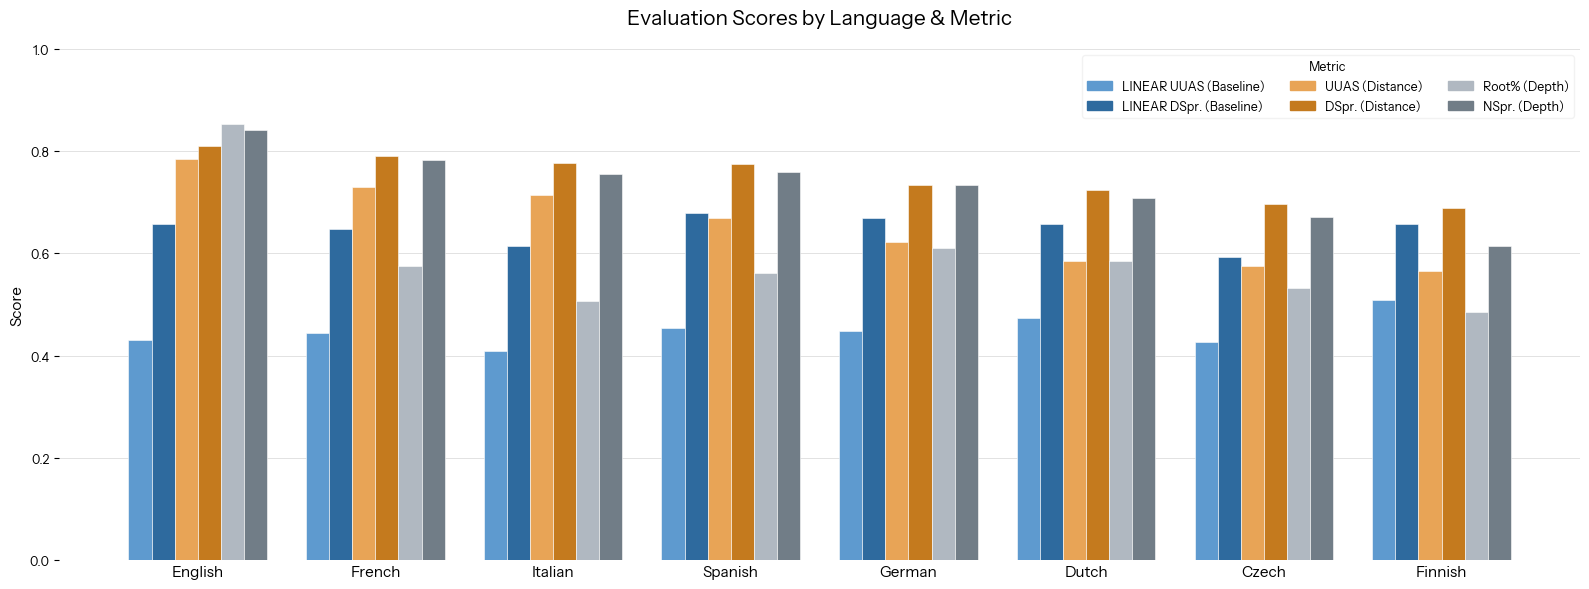

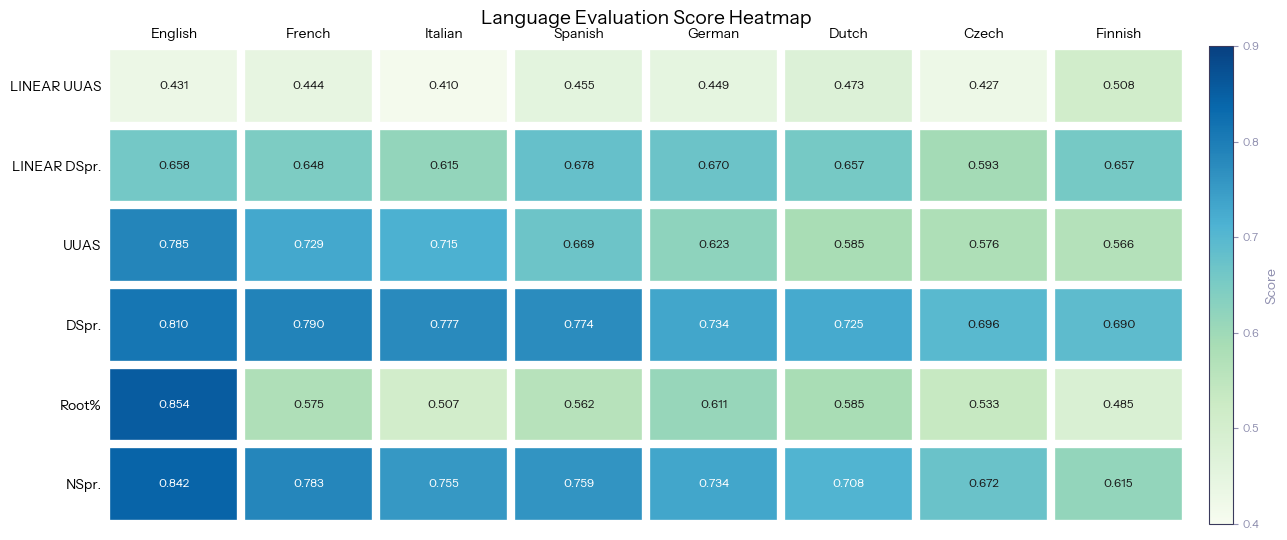

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import requests
import numpy as np

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/visualizations"

# ── Font ──────────────────────────────────────────────────────────────────────
fonts = {
    'InstrumentSans-Regular.ttf': 'https://fonts.gstatic.com/s/instrumentsans/v1/pximypc9vsFDm051Uf6KVwgkfoSxQ0GsQv8ToedPibnr0She1ZuWi3hKpA.ttf',
    'InstrumentSans-Bold.ttf': 'https://fonts.gstatic.com/s/instrumentsans/v1/pximypc9vsFDm051Uf6KVwgkfoSxQ0GsQv8ToedPibnr0SRe1ZuWi3hKpA.ttf',
}

for filename, url in fonts.items():
    r = requests.get(url)
    path = f'/tmp/{filename}'
    with open(path, 'wb') as f:
        f.write(r.content)
    fm.fontManager.addfont(f'{BASE}/InstrumentSans-Regular.ttf')
    fm.fontManager.addfont(f'{BASE}/InstrumentSans-Bold.ttf')

mpl.font_manager._fmcache = {}
plt.rcParams['font.family'] = 'Instrument Sans'

# ── Data ──────────────────────────────────────────────────────────────────────
languages = ['English', 'French', 'Italian', 'Spanish', 'German', 'Dutch', 'Czech', 'Finnish']

data = {
    'LINEAR UUAS':  [0.4307, 0.4435, 0.4096, 0.4545, 0.4486, 0.4730, 0.4270, 0.5084],
    'LINEAR DSpr.': [0.6584, 0.6480, 0.6151, 0.6782, 0.6696, 0.6573, 0.5928, 0.6569],
    'UUAS':         [0.7854, 0.7291, 0.7151, 0.6694, 0.6227, 0.5850, 0.5760, 0.5664],
    'DSpr.':        [0.8104, 0.7905, 0.7770, 0.7741, 0.7338, 0.7247, 0.6961, 0.6895],
    'Root%':        [0.8541, 0.5745, 0.5071, 0.5617, 0.6108, 0.5850, 0.5330, 0.4848],
    'NSpr.':        [0.8424, 0.7832, 0.7547, 0.7595, 0.7338, 0.7076, 0.6718, 0.6153],
}

# Instead of just metric names, add group context
legend_labels = [
    'LINEAR UUAS (Baseline)', 'LINEAR DSpr. (Baseline)',
    'UUAS (Distance)', 'DSpr. (Distance)',
    'Root% (Depth)', 'NSpr. (Depth)'
]

metrics = list(data.keys())
scores  = np.array([data[m] for m in metrics])   # shape (6, 8)

# ── Palette ───────────────────────────────────────────────────────────────────
# Blue + Teal + Sage
BAR_COLORS = ['#5E9ACF', '#2E6A9E',   # Blue light, Blue dark
              '#E8A456', '#C47A1E',   # Orange light, Orange dark
              '#B0B8C1', '#717D87']   # Gray light, Gray dark
CMAP       = 'GnBu'

# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE 1 — Grouped Bar Chart
# ══════════════════════════════════════════════════════════════════════════════
n_langs   = len(languages)
n_metrics = len(metrics)
x         = np.arange(n_langs)
bar_w     = 0.13
offsets   = np.linspace(-(n_metrics - 1) / 2, (n_metrics - 1) / 2, n_metrics) * bar_w

fig1, ax1 = plt.subplots(figsize=(16, 6))
# fig1.patch.set_facecolor('#1C1C2E')
# ax1.set_facecolor('#1C1C2E')

# Instead of '#1C1C2E' / '#0F0F1A', use white:
# fig1.patch.set_facecolor('white')
# ax1.set_facecolor('white')

for i, (metric, color) in enumerate(zip(metrics, BAR_COLORS)):
    bars = ax1.bar(x + offsets[i], scores[i], width=bar_w, label=metric,
               color=color, edgecolor='white', linewidth=0.4, zorder=3)

# Grid & spines
ax1.yaxis.grid(True, color='#DDDDDD', linewidth=0.6, zorder=0)
ax1.set_axisbelow(True)
for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.set_xticks(x)
ax1.set_xticklabels(languages, fontsize=11, color='black')
ax1.tick_params(axis='y', colors='black', labelsize=9)
ax1.tick_params(axis='x', length=0)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Score', color='black', fontsize=11)
ax1.set_title('Evaluation Scores by Language & Metric', color='black',
              fontsize=15, pad=18)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in BAR_COLORS]
legend = ax1.legend(handles, legend_labels, loc='upper right', framealpha=0.25,
           facecolor='white', edgecolor='#cccccc', fontsize=9,
           ncol=3, title='Metric', title_fontsize=9)
legend.get_title().set_color('black')

fig1.tight_layout()
# fig1.savefig(f'{BASE}/bar_chart.png', dpi=150, bbox_inches='tight', facecolor=fig1.get_facecolor())
# fig1.savefig(f'{BASE}/bar_chart.png', dpi=150, bbox_inches='tight', transparent=True)
fig1.savefig('bar_chart.png', dpi=150, bbox_inches='tight', transparent=True)
print("Saved bar_chart.png")


# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE 2 — Heat Map  (6 metrics × 8 languages)
# ══════════════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(13, 5.5))
# fig2.patch.set_facecolor('#0F0F1A')
# ax2.set_facecolor('#0F0F1A')

# Instead of '#1C1C2E' / '#0F0F1A', use white:
# fig2.patch.set_facecolor('white')
# ax2.set_facecolor('white')

im = ax2.imshow(scores, aspect='auto', cmap=CMAP, vmin=0.40, vmax=0.90)
# These must come BEFORE the grid call
ax2.set_xticks(np.arange(-0.5, n_langs, 1), minor=True)
ax2.set_yticks(np.arange(-0.5, n_metrics, 1), minor=True)
ax2.grid(which='minor', color='white', linewidth=6)
ax2.tick_params(which='minor', length=0)

# Draw cell borders + score text
for r in range(n_metrics):
    for c in range(n_langs):
        val = scores[r, c]
        # White text on dark cells, dark text on light cells
        text_color = '#1A1A1A' if val < 0.70 else 'white'
        ax2.text(c, r, f'{val:.3f}', ha='center', va='center',
                 fontsize=8.5, color=text_color)
        # rect = mpatches.FancyBboxPatch(
        #     (c - 0.495, r - 0.495), 0.99, 0.99,
        #     boxstyle='square,pad=0', linewidth=0.8,
        #     edgecolor='#0F0F1A', facecolor='none', zorder=2
        # )
        # ax2.add_patch(rect)

# Axes labels
ax2.set_xticks(range(n_langs))
ax2.set_xticklabels(languages, fontsize=10, color='black')
ax2.set_yticks(range(n_metrics))
ax2.set_yticklabels(metrics, fontsize=10, color='black')
ax2.tick_params(length=0)
ax2.xaxis.set_label_position('top')
ax2.xaxis.tick_top()

ax2.set_title('Language Evaluation Score Heatmap', color='black',
              fontsize=14, pad=16)

# Colorbar
cbar = fig2.colorbar(im, ax=ax2, fraction=0.035, pad=0.02)
cbar.ax.tick_params(colors='#9090B0', labelsize=8)
cbar.outline.set_edgecolor('#3A3A5C')
cbar.set_label('Score', color='#9090B0', fontsize=10)

for spine in ax2.spines.values():
    spine.set_visible(False)

fig2.tight_layout()
# fig2.savefig(f'{BASE}/heatmap.png', dpi=150, bbox_inches='tight', facecolor=fig2.get_facecolor())
# fig2.savefig(f'{BASE}/heatmap.png', dpi=150, bbox_inches='tight', transparent=True)
fig2.savefig('heatmap.png', dpi=150, bbox_inches='tight', transparent=True)
print("Saved heatmap.png")

plt.show()

Saved!


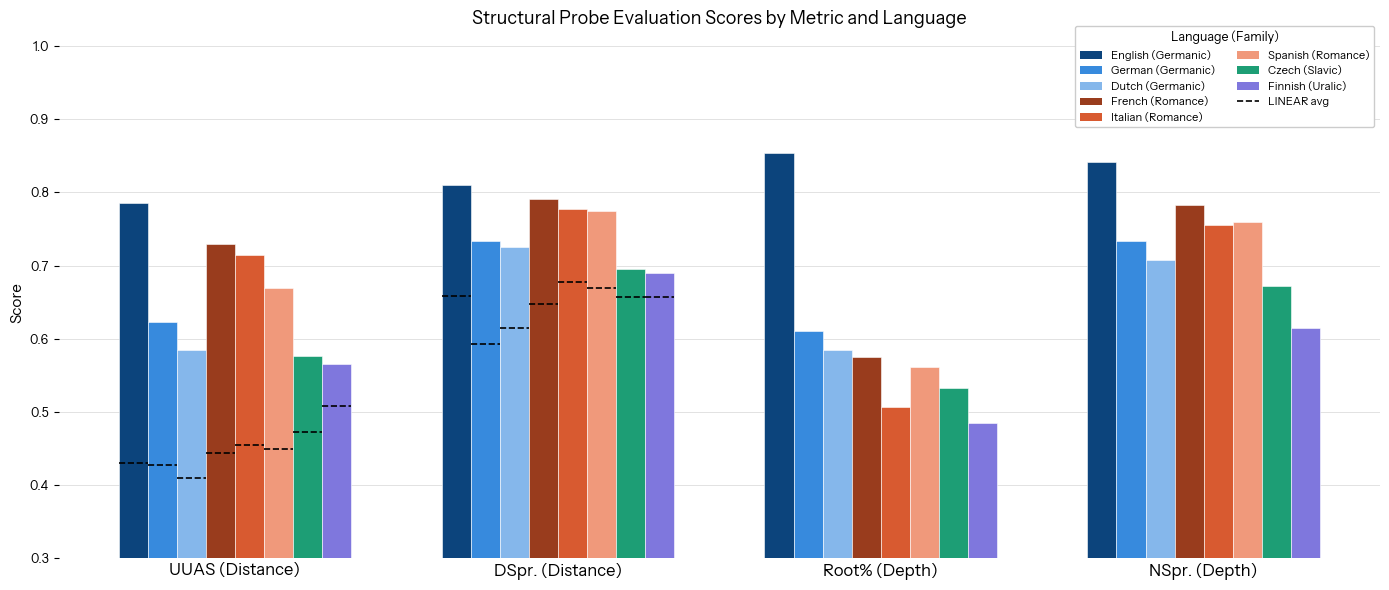

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.font_manager as fm
import requests
import numpy as np

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/visualizations"

# ── Font ──────────────────────────────────────────────────────────────────────
fonts = {
    'InstrumentSans-Regular.ttf': 'https://fonts.gstatic.com/s/instrumentsans/v1/pximypc9vsFDm051Uf6KVwgkfoSxQ0GsQv8ToedPibnr0She1ZuWi3hKpA.ttf',
    'InstrumentSans-Bold.ttf': 'https://fonts.gstatic.com/s/instrumentsans/v1/pximypc9vsFDm051Uf6KVwgkfoSxQ0GsQv8ToedPibnr0SRe1ZuWi3hKpA.ttf',
}

for filename, url in fonts.items():
    r = requests.get(url)
    path = f'/tmp/{filename}'
    with open(path, 'wb') as f:
        f.write(r.content)
    fm.fontManager.addfont(f'{BASE}/InstrumentSans-Regular.ttf')
    fm.fontManager.addfont(f'{BASE}/InstrumentSans-Bold.ttf')

mpl.font_manager._fmcache = {}
plt.rcParams['font.family'] = 'Instrument Sans'

# ── Data ──────────────────────────────────────────────────────────────────────
metrics = ['UUAS (Distance)', 'DSpr. (Distance)', 'Root% (Depth)', 'NSpr. (Depth)']

languages = ['English', 'German', 'Dutch', 'French', 'Italian', 'Spanish', 'Czech', 'Finnish']

probe_data = {
    'UUAS (Distance)':   [0.785, 0.623, 0.585, 0.729, 0.715, 0.669, 0.576, 0.566],
    'DSpr. (Distance)':  [0.810, 0.734, 0.725, 0.791, 0.777, 0.774, 0.696, 0.690],
    'Root% (Depth)':  [0.854, 0.611, 0.585, 0.575, 0.507, 0.562, 0.533, 0.485],
    'NSpr. (Depth)':  [0.842, 0.734, 0.708, 0.783, 0.755, 0.760, 0.672, 0.615],
}

linear_uuas = [0.4307, 0.4270, 0.4096, 0.4435, 0.4545, 0.4486, 0.4730, 0.5084]
linear_dspr = [0.6584, 0.5928, 0.6151, 0.6480, 0.6782, 0.6696, 0.6573, 0.6569]

# ── Colors ────────────────────────────────────────────────────────────────────
# Germanic: blue shades
# Romance: orange/red shades
# Slavic: teal/green
# Uralic: purple
colors = [
    '#0C447C',  # English — darkest blue (Germanic)
    '#378ADD',  # German — mid blue (Germanic)
    '#85B7EB',  # Dutch — light blue (Germanic)
    '#993C1D',  # French — darkest orange (Romance)
    '#D85A30',  # Italian — mid orange (Romance)
    '#F0997B',  # Spanish — light orange (Romance)
    '#1D9E75',  # Czech — teal (Slavic)
    '#7F77DD',  # Finnish — purple (Uralic)
]

# ── Chart ─────────────────────────────────────────────────────────────────────
n_langs   = len(languages)
n_metrics = len(metrics)
x         = np.arange(n_metrics)
bar_w     = 0.09
offsets   = np.linspace(-(n_langs - 1) / 2, (n_langs - 1) / 2, n_langs) * bar_w

fig, ax = plt.subplots(figsize=(14, 6))

for i, lang in enumerate(languages):
    scores = [probe_data[m][i] for m in metrics]
    ax.bar(x + offsets[i], scores, width=bar_w, label=lang,
           color=colors[i], edgecolor='white', linewidth=0.4, zorder=3)

# LINEAR reference lines for UUAS and DSpr. only
# avg_linear_uuas = np.mean(linear_uuas)
# avg_linear_dspr = np.mean(linear_dspr)

# ax.hlines(avg_linear_uuas, x[0] - 0.45, x[0] + 0.45,
#           colors='black', linestyles='dashed', linewidth=1.2, zorder=4)
# ax.hlines(avg_linear_dspr, x[1] - 0.45, x[1] + 0.45,
#           colors='black', linestyles='dashed', linewidth=1.2, zorder=4)

# LINEAR reference lines — one per language per metric
for i, lang in enumerate(languages):
    # UUAS linear line
    ax.hlines(linear_uuas[i], x[0] + offsets[i] - bar_w/2, x[0] + offsets[i] + bar_w/2,
              colors='black', linestyles='dashed', linewidth=1.2, zorder=4)
    # DSpr. linear line
    ax.hlines(linear_dspr[i], x[1] + offsets[i] - bar_w/2, x[1] + offsets[i] + bar_w/2,
              colors='black', linestyles='dashed', linewidth=1.2, zorder=4)

mlines.Line2D([0], [0], color='black', linestyle='dashed',
              linewidth=1.2, label='LINEAR baseline'),

# ── Grid & spines ─────────────────────────────────────────────────────────────
ax.yaxis.grid(True, color='#DDDDDD', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, color='black')
ax.tick_params(axis='y', colors='black', labelsize=9)
ax.tick_params(axis='x', length=0)
ax.set_ylim(0.3, 1.0)
ax.set_ylabel('Score', color='black', fontsize=11)
ax.set_title('Structural Probe Evaluation Scores by Metric and Language',
             color='black', fontsize=13, pad=16)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor='#0C447C', label='English (Germanic)'),
    mpatches.Patch(facecolor='#378ADD', label='German (Germanic)'),
    mpatches.Patch(facecolor='#85B7EB', label='Dutch (Germanic)'),
    mpatches.Patch(facecolor='#993C1D', label='French (Romance)'),
    mpatches.Patch(facecolor='#D85A30', label='Italian (Romance)'),
    mpatches.Patch(facecolor='#F0997B', label='Spanish (Romance)'),
    mpatches.Patch(facecolor='#1D9E75', label='Czech (Slavic)'),
    mpatches.Patch(facecolor='#7F77DD', label='Finnish (Uralic)'),
    mlines.Line2D([0], [0], color='black', linestyle='dashed',
                  linewidth=1.2, label='LINEAR avg'),
]

legend = ax.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(1.0, 1.05),  # raises the legend higher
    fontsize=8,
    framealpha=1.0,              # fully opaque background
    facecolor='white',
    edgecolor='#cccccc',
    ncol=2,
    title='Language (Family)',
    title_fontsize=9,
)
legend.get_title().set_color('black')

fig.tight_layout()
fig.savefig(f'{BASE}/rosetta_probe_bar_chart.png', dpi=150, bbox_inches='tight')
fig.savefig('rosetta_probe_bar_chart.png', dpi=150, bbox_inches='tight')
print("Saved!")
plt.show()




Saved individual_metrics.png
Saved linear_baseline_charts.png


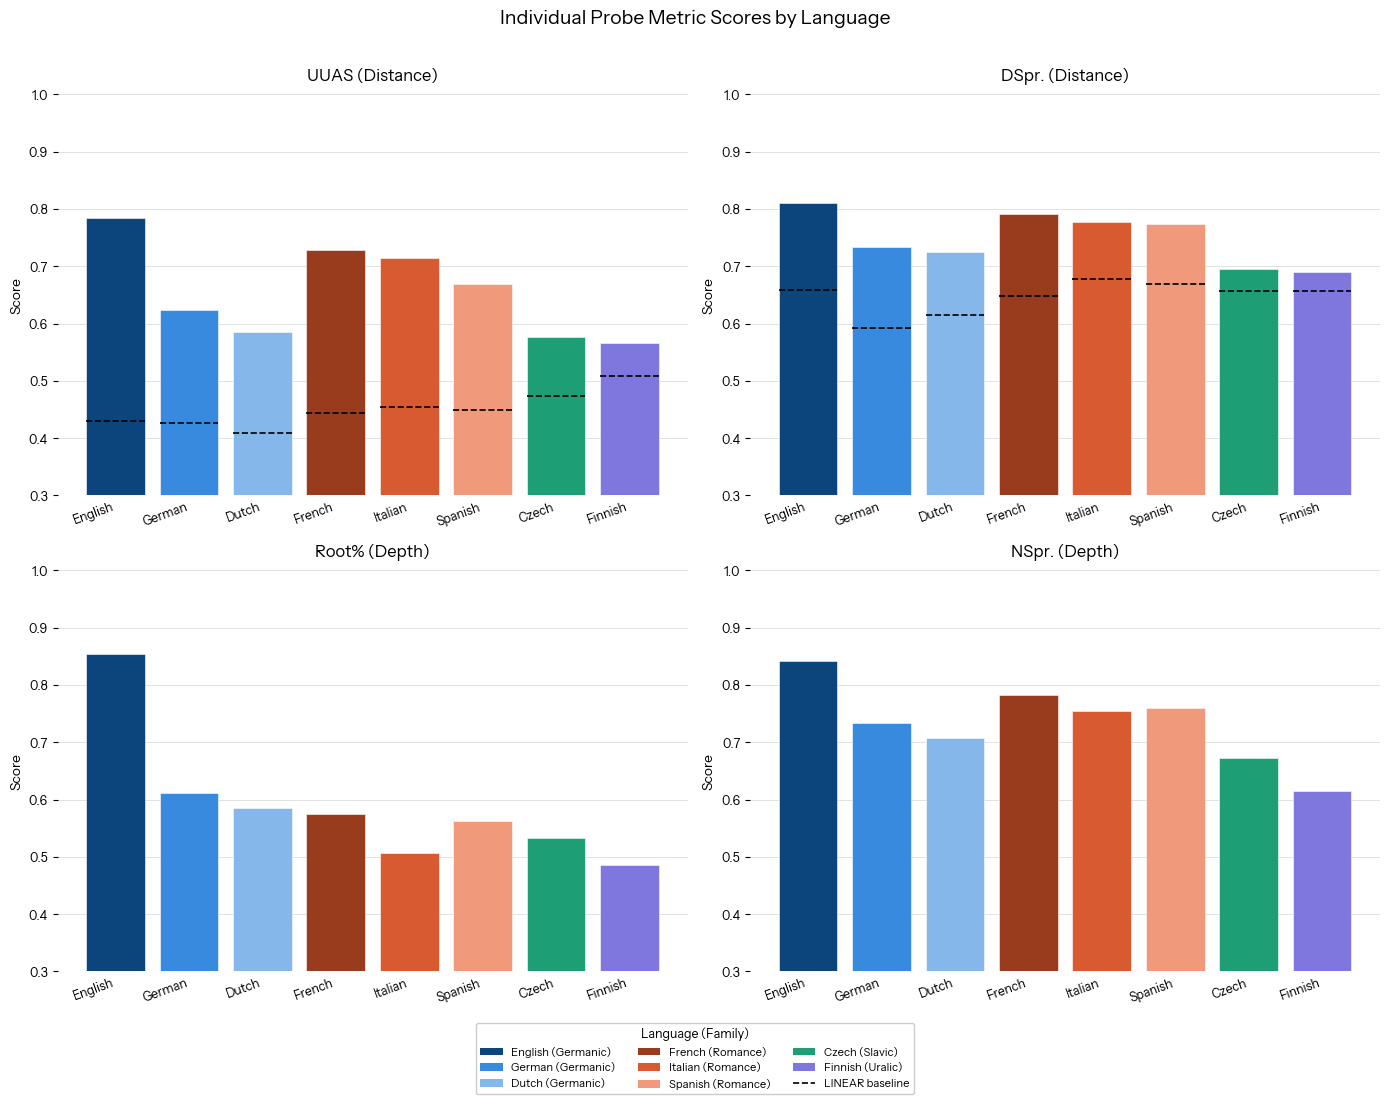

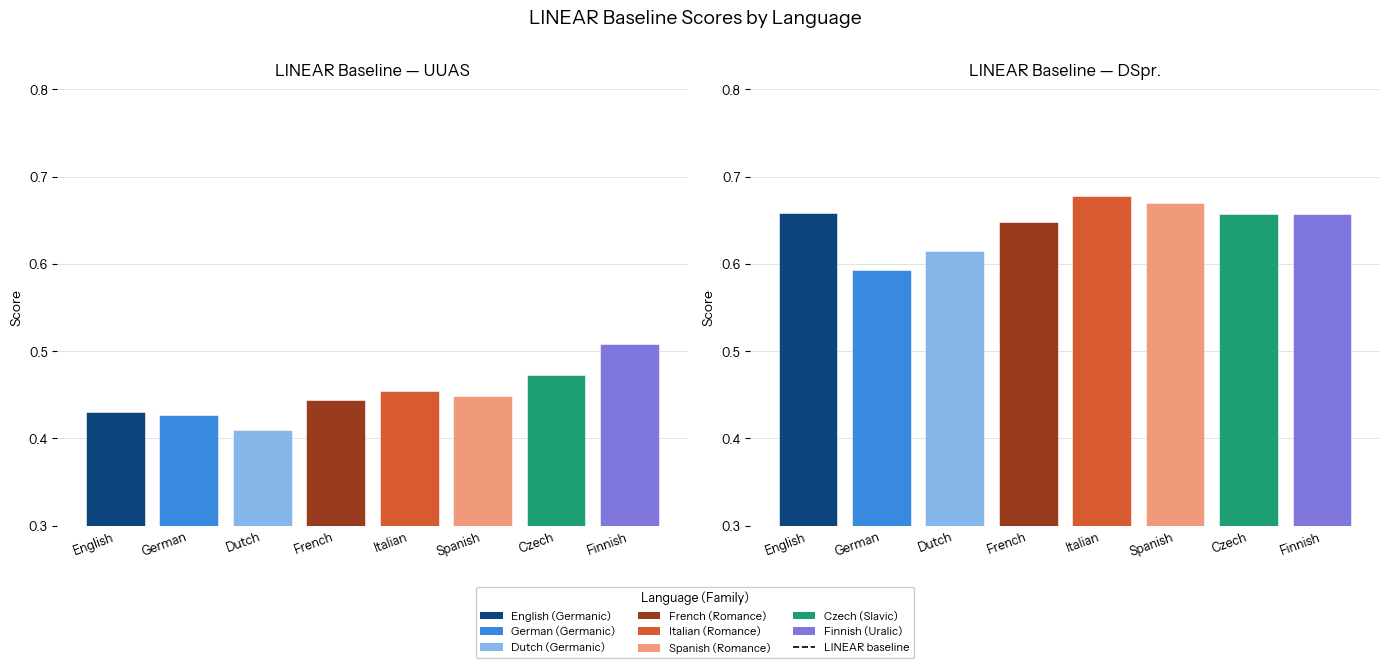

In [36]:
# Individual evaluation metric charts

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.font_manager as fm
import requests
import numpy as np

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe/visualizations"

# ── Font ──────────────────────────────────────────────────────────────────────
fonts = {
    'InstrumentSans-Regular.ttf': 'https://fonts.gstatic.com/s/instrumentsans/v1/pximypc9vsFDm051Uf6KVwgkfoSxQ0GsQv8ToedPibnr0She1ZuWi3hKpA.ttf',
    'InstrumentSans-Bold.ttf': 'https://fonts.gstatic.com/s/instrumentsans/v1/pximypc9vsFDm051Uf6KVwgkfoSxQ0GsQv8ToedPibnr0SRe1ZuWi3hKpA.ttf',
}

for filename, url in fonts.items():
    r = requests.get(url)
    path = f'/tmp/{filename}'
    with open(path, 'wb') as f:
        f.write(r.content)
    fm.fontManager.addfont(f'{BASE}/InstrumentSans-Regular.ttf')
    fm.fontManager.addfont(f'{BASE}/InstrumentSans-Bold.ttf')

mpl.font_manager._fmcache = {}
plt.rcParams['font.family'] = 'Instrument Sans'

# ── Data ──────────────────────────────────────────────────────────────────────
languages = ['English', 'German', 'Dutch', 'French', 'Italian', 'Spanish', 'Czech', 'Finnish']

probe_data = {
    'UUAS':   [0.785, 0.623, 0.585, 0.729, 0.715, 0.669, 0.576, 0.566],
    'DSpr.':  [0.810, 0.734, 0.725, 0.791, 0.777, 0.774, 0.696, 0.690],
    'Root%':  [0.854, 0.611, 0.585, 0.575, 0.507, 0.562, 0.533, 0.485],
    'NSpr.':  [0.842, 0.734, 0.708, 0.783, 0.755, 0.760, 0.672, 0.615],
}

linear_uuas = [0.4307, 0.4270, 0.4096, 0.4435, 0.4545, 0.4486, 0.4730, 0.5084]
linear_dspr = [0.6584, 0.5928, 0.6151, 0.6480, 0.6782, 0.6696, 0.6573, 0.6569]

colors = [
    '#0C447C', '#378ADD', '#85B7EB',
    '#993C1D', '#D85A30', '#F0997B',
    '#1D9E75',
    '#7F77DD',
]

legend_elements = [
    mpatches.Patch(facecolor='#0C447C', label='English (Germanic)'),
    mpatches.Patch(facecolor='#378ADD', label='German (Germanic)'),
    mpatches.Patch(facecolor='#85B7EB', label='Dutch (Germanic)'),
    mpatches.Patch(facecolor='#993C1D', label='French (Romance)'),
    mpatches.Patch(facecolor='#D85A30', label='Italian (Romance)'),
    mpatches.Patch(facecolor='#F0997B', label='Spanish (Romance)'),
    mpatches.Patch(facecolor='#1D9E75', label='Czech (Slavic)'),
    mpatches.Patch(facecolor='#7F77DD', label='Finnish (Uralic)'),
    mlines.Line2D([0], [0], color='black', linestyle='dashed',
                  linewidth=1.2, label='LINEAR baseline'),
]

def style_ax(ax, title, ylim=(0.3, 1.0)):
    ax.yaxis.grid(True, color='#DDDDDD', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(range(len(languages)))
    ax.set_xticklabels(languages, fontsize=9, rotation=20, ha='right', color='black')
    ax.tick_params(axis='y', colors='black', labelsize=9)
    ax.tick_params(axis='x', length=0)
    ax.set_ylim(*ylim)
    ax.set_ylabel('Score', color='black', fontsize=10)
    ax.set_title(title, color='black', fontsize=12, pad=10)

def add_legend(fig):
    legend = fig.legend(
        handles=legend_elements,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.08),  # below the figure
        fontsize=8,
        framealpha=1.0,
        facecolor='white',
        edgecolor='#cccccc',
        ncol=3,
        title='Language (Family)',
        title_fontsize=9,
    )
    legend.get_title().set_color('black')

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Individual probe metrics (2x2 grid)
# ══════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metric_titles = ['UUAS (Distance)', 'DSpr. (Distance)', 'Root% (Depth)', 'NSpr. (Depth)']

for idx, (metric, title) in enumerate(zip(probe_data.keys(), metric_titles)):
    ax = axes[idx]
    for i, lang in enumerate(languages):
        ax.bar(i, probe_data[metric][i], color=colors[i],
               edgecolor='white', linewidth=0.4, zorder=3)
        if metric == 'UUAS':
            ax.hlines(linear_uuas[i], i - 0.4, i + 0.4,
                      colors='black', linestyles='dashed', linewidth=1.2, zorder=4)
        elif metric == 'DSpr.':
            ax.hlines(linear_dspr[i], i - 0.4, i + 0.4,
                      colors='black', linestyles='dashed', linewidth=1.2, zorder=4)
    style_ax(ax, title)

fig1.suptitle('Individual Probe Metric Scores by Language',
              fontsize=14, color='black', y=1.01)
add_legend(fig1)
fig1.tight_layout()
fig1.savefig(f'{BASE}/individual_metrics.png', dpi=150, bbox_inches='tight')
fig1.savefig('individual_metrics.png', dpi=150, bbox_inches='tight')
print("Saved individual_metrics.png")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — LINEAR baseline charts (side by side)
# ══════════════════════════════════════════════════════════════════════════════
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, title in zip(
    [ax1, ax2],
    [linear_uuas, linear_dspr],
    ['LINEAR Baseline — UUAS', 'LINEAR Baseline — DSpr.']
):
    for i, score in enumerate(data):
        ax.bar(i, score, color=colors[i], edgecolor='white', linewidth=0.4, zorder=3)
    style_ax(ax, title, ylim=(0.3, 0.8))

fig2.suptitle('LINEAR Baseline Scores by Language',
              fontsize=14, color='black', y=1.01)
add_legend(fig2)
fig2.tight_layout()
fig2.subplots_adjust(bottom=0.15)  # add this line before savefig

fig2.savefig(f'{BASE}/linear_baseline_charts.png', dpi=150, bbox_inches='tight')
fig2.savefig('linear_baseline_charts.png', dpi=150, bbox_inches='tight')
print("Saved linear_baseline_charts.png")

plt.show()

#### Parse Tree Access

In [ ]:
# TIKZ Reader - French

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
with open(f"{BASE}/results/fr/fr-gsd-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-23-35-55-731634/dev.tikz") as f:
    content = f.read()
print(content[:3000])  # print first 3000 characters to see a few examples



\begin{dependency}[hide label, edge unit distance=.5ex]
    \begin{deptext}[column sep=0.05cm]
    Aviator\& ,\& un\& film\& sur\& la\& vie\& de\& Hughes\& . \\
\end{deptext}
\depedge{1}{4}{.}
\depedge{3}{4}{.}
\depedge{4}{7}{.}
\depedge{5}{7}{.}
\depedge{6}{7}{.}
\depedge{7}{9}{.}
\depedge{8}{9}{.}
\depedge[edge style={red!60!}, edge below]{3}{4}{.}
\depedge[edge style={red!60!}, edge below]{6}{7}{.}
\depedge[edge style={red!60!}, edge below]{1}{4}{.}
\depedge[edge style={red!60!}, edge below]{5}{7}{.}
\depedge[edge style={red!60!}, edge below]{4}{7}{.}
\depedge[edge style={red!60!}, edge below]{8}{9}{.}
\depedge[edge style={red!60!}, edge below]{7}{9}{.}
\end{dependency}


\begin{dependency}[hide label, edge unit distance=.5ex]
    \begin{deptext}[column sep=0.05cm]
    Les\& études\& durent\& six\& ans\& mais\& leur\& contenu\& diffère\& donc\& selon\& les\& Facultés\& . \\
\end{deptext}
\depedge{1}{2}{.}
\depedge{2}{3}{.}
\depedge{3}{5}{.}
\depedge{3}{9}{.}
\depedge{4}{5}{.}
\dep

In [ ]:
# TIKZ Reader - German

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
with open(f"{BASE}/results/de/de-gsd-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-17-15-20-217531/dev.tikz") as f:
    content = f.read()
print(content[:3000])  # print first 3000 characters to see a few examples



\begin{dependency}[hide label, edge unit distance=.5ex]
    \begin{deptext}[column sep=0.05cm]
    Manasse\& ist\& ein\& einzigartiger\& Parfümeur\& . \\
\end{deptext}
\depedge{1}{5}{.}
\depedge{2}{5}{.}
\depedge{3}{5}{.}
\depedge{4}{5}{.}
\depedge[edge style={red!60!}, edge below]{3}{4}{.}
\depedge[edge style={red!60!}, edge below]{4}{5}{.}
\depedge[edge style={red!60!}, edge below]{1}{5}{.}
\depedge[edge style={red!60!}, edge below]{2}{5}{.}
\end{dependency}


\begin{dependency}[hide label, edge unit distance=.5ex]
    \begin{deptext}[column sep=0.05cm]
    Ich\& hatte\& Gelegenheit\& eines\& seiner\& Seminare\& zu\& besuchen\& . \\
\end{deptext}
\depedge{1}{2}{.}
\depedge{2}{3}{.}
\depedge{3}{8}{.}
\depedge{4}{6}{.}
\depedge{5}{6}{.}
\depedge{6}{8}{.}
\depedge{7}{8}{.}
\depedge[edge style={red!60!}, edge below]{2}{3}{.}
\depedge[edge style={red!60!}, edge below]{7}{8}{.}
\depedge[edge style={red!60!}, edge below]{6}{8}{.}
\depedge[edge style={red!60!}, edge below]{3}{6}{.}
\depedg

In [ ]:
# TIKZ Reader - Finnish

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"
with open(f"{BASE}/results/fi/fi-tdt-pad-bert-base7/BERT-disk-parse-distance-2026-3-11-3-53-30-793251/dev.tikz") as f:
    content = f.read()
print(content[:3000])  # print first 3000 characters to see a few examples



\begin{dependency}[hide label, edge unit distance=.5ex]
    \begin{deptext}[column sep=0.05cm]
    The\& Garden\& Collection\& by\& H+M \\
\end{deptext}
\depedge{1}{2}{.}
\depedge{1}{3}{.}
\depedge{1}{4}{.}
\depedge{1}{5}{.}
\depedge[edge style={red!60!}, edge below]{1}{5}{.}
\depedge[edge style={red!60!}, edge below]{3}{5}{.}
\depedge[edge style={red!60!}, edge below]{4}{5}{.}
\depedge[edge style={red!60!}, edge below]{2}{5}{.}
\end{dependency}


\begin{dependency}[hide label, edge unit distance=.5ex]
    \begin{deptext}[column sep=0.05cm]
    Viikonlopun\& pyöritys\& alkoi\& H+M:n\& järjestämällä\& bloggaajabrunssilla\& Helsingissä\& . \\
\end{deptext}
\depedge{1}{2}{.}
\depedge{2}{3}{.}
\depedge{3}{6}{.}
\depedge{3}{7}{.}
\depedge{4}{5}{.}
\depedge{5}{6}{.}
\depedge[edge style={red!60!}, edge below]{2}{3}{.}
\depedge[edge style={red!60!}, edge below]{1}{2}{.}
\depedge[edge style={red!60!}, edge below]{2}{4}{.}
\depedge[edge style={red!60!}, edge below]{4}{5}{.}
\depedge[edge style

In [ ]:
# Checking English sentences in Finnish data

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

english_count = 0
total = 0
with open(f"{BASE}/data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.conllu") as f:
    current_sentence = []
    for line in f:
        if line.startswith('#'):
            continue
        if not line.strip():
            if current_sentence:
                # Check if sentence looks English (simple heuristic: common English words)
                words = [w.lower() for w in current_sentence]
                english_words = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'by', 'of', 'and', 'in'}
                matches = sum(1 for w in words if w in english_words)
                if matches >= 2:
                    english_count += 1
                    print(f"Possible English sentence: {' '.join(current_sentence)}")
                total += 1
                current_sentence = []
        else:
            fields = line.strip().split('\t')
            if fields[0].isdigit():
                current_sentence.append(fields[1])

print(f"\nTotal sentences: {total}")
print(f"Possible English sentences: {english_count}")

Possible English sentence: The Garden Collection by H&M
Possible English sentence: " eläinlääkintäalaa koskevalla lainsäädännöllä " : direktiivin 89/662/ETY liitteessä A ja direktiivin 90/425/ETY liitteissä A ja B tarkoitettua lainsäädäntöa ;
Possible English sentence: I Wanna Be Adored rock-yhtye The Stone Rosesin kolmas singlejulkaisu albumilta The Stone Roses .
Possible English sentence: Hänen tunnetuin yksittäinen kappaleensa on ” Walking in the Air ” ( 1982 ) , joka sisältyy Lumiukko-elokuvan musiikkiin .

Total sentences: 1363
Possible English sentences: 4


In [25]:
import re

def analyze_tikz(filepath, lang):
    with open(filepath) as f:
        content = f.read()

    # Split into individual dependency blocks
    blocks = content.strip().split('\\begin{dependency}')
    blocks = [b for b in blocks if b.strip()]

    results = []
    for block in blocks:
        # Extract words
        words_match = re.search(r'\\begin{deptext}.*?\\end{deptext}', block, re.DOTALL)
        if not words_match:
            continue
        words_text = words_match.group()
        words = [w.strip() for w in re.findall(r'([^\\&\n]+)(?:\\&|\\\\)', words_text)]
        words = [w for w in words if w]
        punct = {'.', ',', '?', '!', ':', ';', '"', "'", '«', '»', '(', ')'}
        content_words = [w for w in words if w not in punct]
        n_words = len(content_words)

        # Extract gold edges (no red style)
        gold_edges = set(re.findall(r'\\depedge\{(\d+)\}\{(\d+)\}', block))
        gold_edges -= set(re.findall(r'edge style=\{red.*?\}.*?\\depedge\{(\d+)\}\{(\d+)\}', block))

        # Extract predicted edges (red)
        pred_section = re.findall(r'edge style=\{red[^}]*\}[^\\]*\\depedge\{(\d+)\}\{(\d+)\}', block)
        pred_edges = set(pred_section)

        # Simpler approach - count total depedges vs red depedges
        all_depedges = re.findall(r'\\depedge(?!\[)\{(\d+)\}\{(\d+)\}', block)
        red_depedges = re.findall(r'\\depedge\[edge style=\{red[^}]*\}[^\]]*\]\{(\d+)\}\{(\d+)\}', block)

        gold_set = set(map(tuple, all_depedges))
        pred_set = set(map(tuple, red_depedges))

        if not gold_set or not pred_set:
            continue

        # Calculate overlap
        overlap = len(gold_set & pred_set)
        match_rate = overlap / len(gold_set) if gold_set else 0

        results.append({
            'words': words,
            'n_words': n_words,
            'gold': gold_set,
            'pred': pred_set,
            'match_rate': match_rate,
            'overlap': overlap,
            'total_gold': len(gold_set)
        })

    return results

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

# Analyze each language - update timestamps!
files = {
    'French': f"{BASE}/results/fr/fr-gsd-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-23-35-55-731634/dev.tikz",
    'German': f"{BASE}/results/de/de-gsd-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-17-15-20-217531/dev.tikz",
    'Finnish': f"{BASE}/results/fi/fi-tdt-pad-bert-base7/BERT-disk-parse-distance-2026-3-11-3-53-30-793251/dev.tikz",
}

for lang, filepath in files.items():
    print(f"\n=== {lang} ===")
    results = analyze_tikz(filepath, lang)

    # Find best examples in different match rate ranges
    # Perfect matches (short sentences)
    perfect = [(r, i) for i, r in enumerate(results) if r['match_rate'] == 1.0 and 5 <= r['n_words'] <= 20]
    # Partial matches
    partial = [(r, i) for i, r in enumerate(results) if 0.5 <= r['match_rate'] < 1.0 and 5 <= r['n_words'] <= 20]
    # Poor matches
    poor = [(r, i) for i, r in enumerate(results) if r['match_rate'] < 0.5 and 5 <= r['n_words'] <= 20]

    print(f"Perfect matches (5-20 words): {len(perfect)}")
    for r, i in sorted(perfect, key=lambda x: x[0]['n_words']):
        print(f"  '{' '.join(r['words'])}' (match: {r['match_rate']:.2f}, {r['n_words']} words)")

    print(f"Partial matches (5-20 words): {len(partial)}")
    for r, i in sorted(partial, key=lambda x: x[0]['n_words']):
        print(f"  '{' '.join(r['words'])}' (match: {r['match_rate']:.2f}, {r['n_words']} words)")

    print(f"Poor matches (5-20 words): {len(poor)}")
    for r, i in sorted(poor, key=lambda x: x[0]['n_words']):
        print(f"  '{' '.join(r['words'])}' (match: {r['match_rate']:.2f}, {r['n_words']} words)")


=== French ===
Perfect matches (5-20 words): 2
  'Aviator , un film sur la vie de Hughes .' (match: 1.00, 8 words)
  'Mais comment faire dans un contexte structurellement raciste ?' (match: 1.00, 8 words)
Partial matches (5-20 words): 7
  'Elle lutte pour échapper à les tueurs à ses trousses .' (match: 0.89, 10 words)
  'Mais , le SMIC n' est pas un outil de référence .' (match: 0.56, 10 words)
  'Travail de très grande qualité exécuté par un imprimeur artisan passionné .' (match: 0.70, 11 words)
  'Les compagnies aériennes à bas coût ne connaissent pas la crise .' (match: 0.80, 11 words)
  'C' est véritablement pour le futur baptisé un changement de cap .' (match: 0.50, 11 words)
  'Les études durent six ans mais leur contenu diffère donc selon les Facultés .' (match: 0.67, 13 words)
  'L' Abime de l' abime de Vladimir Holan à la Maison d' Arrêt d' Avignon ( 2001 ) .' (match: 0.73, 16 words)
Poor matches (5-20 words): 0

=== German ===
Perfect matches (5-20 words): 1
  'Ob Dekoration

In [27]:
# Core paper parse trees - distance probe

import re

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

def get_tikz_block(filepath, target_sentence):
    with open(filepath) as f:
        content = f.read()
    blocks = content.strip().split('\\begin{dependency}')
    blocks = [b for b in blocks if b.strip()]
    for block in blocks:
        words_match = re.search(r'\\begin{deptext}.*?\\end{deptext}', block, re.DOTALL)
        if not words_match:
            continue
        words_text = words_match.group()
        words = [w.strip() for w in re.findall(r'([^\\&\n]+)(?:\\&|\\\\)', words_text)]
        words = [w for w in words if w]
        sentence = ' '.join(words)
        if target_sentence in sentence:
            print("\\begin{dependency}" + block)
            print("---END---")
            return
    print(f"Not found: {target_sentence}")

# Distance Probe Results

get_tikz_block(
    f"{BASE}/results/de/de-gsd-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-17-15-20-217531/dev.tikz",
    "Ich kann dieses Geschäft"
)

get_tikz_block(
    f"{BASE}/results/fr/fr-gsd-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-23-35-55-731634/dev.tikz",
    "Mais comment faire dans"
)

get_tikz_block(
    f"{BASE}/results/fi/fi-tdt-pad-bert-base7/BERT-disk-parse-distance-2026-3-11-3-53-30-793251/dev.tikz",
    "Saavuin siis kaupunkiin"
)

\begin{dependency}[hide label, edge unit distance=.5ex]
    \begin{deptext}[column sep=0.05cm]
    Ich\& kann\& dieses\& Geschäft\& nur\& wärmstens\& empfehlen\& . \\
\end{deptext}
\depedge{1}{7}{.}
\depedge{2}{7}{.}
\depedge{3}{4}{.}
\depedge{4}{7}{.}
\depedge{5}{6}{.}
\depedge{6}{7}{.}
\depedge[edge style={red!60!}, edge below]{6}{7}{.}
\depedge[edge style={red!60!}, edge below]{4}{7}{.}
\depedge[edge style={red!60!}, edge below]{5}{7}{.}
\depedge[edge style={red!60!}, edge below]{2}{7}{.}
\depedge[edge style={red!60!}, edge below]{1}{7}{.}
\depedge[edge style={red!60!}, edge below]{3}{4}{.}
\end{dependency}
---END---
\begin{dependency}[hide label, edge unit distance=.5ex]
    \begin{deptext}[column sep=0.05cm]
    Mais\& comment\& faire\& dans\& un\& contexte\& structurellement\& raciste\& ? \\
\end{deptext}
\depedge{1}{3}{.}
\depedge{2}{3}{.}
\depedge{3}{6}{.}
\depedge{4}{6}{.}
\depedge{5}{6}{.}
\depedge{6}{8}{.}
\depedge{7}{8}{.}
\depedge[edge style={red!60!}, edge below]{5}{6}{.}

In [ ]:
# Appendix Parse Trees

import re

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

def analyze_tikz(filepath):
    with open(filepath) as f:
        content = f.read()
    blocks = content.strip().split('\\begin{dependency}')
    blocks = [b for b in blocks if b.strip()]
    results = []
    for block in blocks:
        words_match = re.search(r'\\begin{deptext}.*?\\end{deptext}', block, re.DOTALL)
        if not words_match:
            continue
        words_text = words_match.group()
        words = [w.strip() for w in re.findall(r'([^\\&\n]+)(?:\\&|\\\\)', words_text)]
        words = [w for w in words if w]
        punct = {'.', ',', '?', '!', ':', ';', '"', "'", '«', '»', '(', ')'}
        content_words = [w for w in words if w not in punct]
        n_words = len(content_words)
        all_depedges = re.findall(r'\\depedge(?!\[)\{(\d+)\}\{(\d+)\}', block)
        red_depedges = re.findall(r'\\depedge\[edge style=\{red[^}]*\}[^\]]*\]\{(\d+)\}\{(\d+)\}', block)
        gold_set = set(map(tuple, all_depedges))
        pred_set = set(map(tuple, red_depedges))
        if not gold_set or not pred_set:
            continue
        overlap = len(gold_set & pred_set)
        match_rate = overlap / len(gold_set) if gold_set else 0
        results.append({
            'words': words,
            'n_words': n_words,
            'gold': gold_set,
            'pred': pred_set,
            'match_rate': match_rate,
            'overlap': overlap,
            'total_gold': len(gold_set)
        })
    return results

# Update timestamps for each language!
files = {
    'English':  f"{BASE}/results/en/en-ewt-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-15-39-28-606938/dev.tikz",
    'German':   f"{BASE}/results/de/de-gsd-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-17-15-20-217531/dev.tikz",
    'Dutch':    f"{BASE}/results/nl/nl-alpino-pad-bert-base7/BERT-disk-parse-distance-2026-3-10-6-11-52-788826/dev.tikz",
    'French':   f"{BASE}/results/fr/fr-gsd-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-23-35-55-731634/dev.tikz",
    'Italian':  f"{BASE}/results/it/it-isdt-pad-bert-base7/BERT-disk-parse-distance-2026-3-10-17-22-2-619591/dev.tikz",
    'Spanish':  f"{BASE}/results/es/es-ancora-pad-bert-base7/BERT-disk-parse-distance-2026-3-10-0-31-40-905310/dev.tikz",
    'Czech':    f"{BASE}/results/cs/cs-pdtc-pad-bert-base7/BERT-disk-parse-distance-2026-3-10-1-35-17-78874/dev.tikz",
    'Finnish':  f"{BASE}/results/fi/fi-tdt-pad-bert-base7/BERT-disk-parse-distance-2026-3-11-3-53-30-793251/dev.tikz",
}

for lang, filepath in files.items():
    print(f"\n=== {lang} ===")
    try:
        results = analyze_tikz(filepath)
        perfect = [(r, i) for i, r in enumerate(results) if r['match_rate'] == 1.0 and 10 <= r['n_words'] <= 20]
        partial = [(r, i) for i, r in enumerate(results) if 0.5 <= r['match_rate'] < 1.0 and 10 <= r['n_words'] <= 20]
        poor    = [(r, i) for i, r in enumerate(results) if r['match_rate'] < 0.5 and 10 <= r['n_words'] <= 20]

        print(f"Perfect matches (10-20 words): {len(perfect)}")
        if perfect:
            best = sorted(perfect, key=lambda x: x[0]['n_words'])[0]
            print(f"  Best: '{' '.join(best[0]['words'])}' (match: {best[0]['match_rate']:.2f}, {best[0]['n_words']} words)")

        print(f"Partial matches (10-20 words): {len(partial)}")
        if partial:
            best = sorted(partial, key=lambda x: x[0]['n_words'])[0]
            print(f"  Best: '{' '.join(best[0]['words'])}' (match: {best[0]['match_rate']:.2f}, {best[0]['n_words']} words)")

        print(f"Poor matches (10-20 words): {len(poor)}")
        if poor:
            best = sorted(poor, key=lambda x: x[0]['n_words'])[0]
            print(f"  Best: '{' '.join(best[0]['words'])}' (match: {best[0]['match_rate']:.2f}, {best[0]['n_words']} words)")

    except FileNotFoundError:
        print(f"  FILE NOT FOUND — update timestamp")


=== English ===
Perfect matches (10-20 words): 1
  Best: 'The US troops fired into the hostile crowd , killing 4 .' (match: 1.00, 10 words)
Partial matches (10-20 words): 6
  Best: 'Today 's incident proves that Sharon has lost his patience and his hope in peace .' (match: 0.79, 15 words)
Poor matches (10-20 words): 0

=== German ===
Perfect matches (10-20 words): 1
  Best: 'Ob Dekoration oder Feuerwerk , ich bin begeistert von der Auswahl und der Qualität .' (match: 1.00, 13 words)
Partial matches (10-20 words): 6
  Best: 'Nach einem viertel Jahr hielt ich ein duftendes Wunder in den Händen .' (match: 0.82, 12 words)
Poor matches (10-20 words): 0

=== Dutch ===
Perfect matches (10-20 words): 0
Partial matches (10-20 words): 7
  Best: 'Waarmee het pad voor de rappe Van Alebeek werd geëffend .' (match: 0.67, 10 words)
Poor matches (10-20 words): 2
  Best: 'Met venijnige demarrages matte de talentvolle Kaagman de concurrentie af .' (match: 0.44, 10 words)

=== French ===
Perfect matches

In [ ]:
import re

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

def get_tikz_block(filepath, target_sentence):
    with open(filepath) as f:
        content = f.read()
    blocks = content.strip().split('\\begin{dependency}')
    blocks = [b for b in blocks if b.strip()]
    for block in blocks:
        words_match = re.search(r'\\begin{deptext}.*?\\end{deptext}', block, re.DOTALL)
        if not words_match:
            continue
        words_text = words_match.group()
        words = [w.strip() for w in re.findall(r'([^\\&\n]+)(?:\\&|\\\\)', words_text)]
        words = [w for w in words if w]
        sentence = ' '.join(words)
        if target_sentence in sentence:
            print("\\begin{dependency}" + block)
            print("---END---")
            return
    print(f"Not found: {target_sentence}")

get_tikz_block(
    f"{BASE}/results/en/en-ewt-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-15-39-28-606938/dev.tikz",
    "US troops fired"
)
get_tikz_block(
    f"{BASE}/results/de/de-gsd-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-17-15-20-217531/dev.tikz",
    "Ob Dekoration oder Feuerwerk"
)
get_tikz_block(
    f"{BASE}/results/nl/nl-alpino-pad-bert-base7/BERT-disk-parse-distance-2026-3-10-6-11-52-788826/dev.tikz",
    "Van Alebeek"
)
get_tikz_block(
    f"{BASE}/results/fr/fr-gsd-pad-bert-base7/BERT-disk-parse-distance-2026-3-9-23-35-55-731634/dev.tikz",
    "Elle lutte pour échapper"
)
get_tikz_block(
    f"{BASE}/results/it/it-isdt-pad-bert-base7/BERT-disk-parse-distance-2026-3-10-17-22-2-619591/dev.tikz",
    "tre avevano"
)
get_tikz_block(
    f"{BASE}/results/es/es-ancora-pad-bert-base7/BERT-disk-parse-distance-2026-3-10-0-31-40-905310/dev.tikz",
    "Desde entonces entró"
)
get_tikz_block(
    f"{BASE}/results/cs/cs-pdtc-pad-bert-base7/BERT-disk-parse-distance-2026-3-10-1-35-17-78874/dev.tikz",
    "silniční daň"
)
get_tikz_block(
    f"{BASE}/results/fi/fi-tdt-pad-bert-base7/BERT-disk-parse-distance-2026-3-11-3-53-30-793251/dev.tikz",
    "Peppi ja Mimmi"
)

\begin{dependency}[hide label, edge unit distance=.5ex]
    \begin{deptext}[column sep=0.05cm]
    The\& US\& troops\& fired\& into\& the\& hostile\& crowd\& ,\& killing\& 4\& . \\
\end{deptext}
\depedge{1}{3}{.}
\depedge{2}{3}{.}
\depedge{3}{4}{.}
\depedge{4}{8}{.}
\depedge{4}{10}{.}
\depedge{5}{8}{.}
\depedge{6}{8}{.}
\depedge{7}{8}{.}
\depedge{10}{11}{.}
\depedge[edge style={red!60!}, edge below]{3}{4}{.}
\depedge[edge style={red!60!}, edge below]{1}{3}{.}
\depedge[edge style={red!60!}, edge below]{2}{3}{.}
\depedge[edge style={red!60!}, edge below]{6}{8}{.}
\depedge[edge style={red!60!}, edge below]{7}{8}{.}
\depedge[edge style={red!60!}, edge below]{4}{8}{.}
\depedge[edge style={red!60!}, edge below]{5}{8}{.}
\depedge[edge style={red!60!}, edge below]{10}{11}{.}
\depedge[edge style={red!60!}, edge below]{4}{10}{.}
\end{dependency}



---END---
\begin{dependency}[hide label, edge unit distance=.5ex]
    \begin{deptext}[column sep=0.05cm]
    Ob\& Dekoration\& oder\& Feuerwerk\& ,\&

#### Sentence Counts

In [ ]:
import os

BASE = "/content/drive/MyDrive/5th Year/Winter Quarter, 2026/CS 224N/cs224n-structural-probe"

datasets = {
    'English': {
        'train': 'data/en/UD_English-EWT/en_ewt-ud-train-11k.conllu',
        'dev': 'data/en/UD_English-EWT/en_ewt-ud-dev.conllu',
        'test': 'data/en/UD_English-EWT/en_ewt-ud-test.conllu',
    },
    'German': {
        'train': 'data/de/UD_German-GSD/de_gsd-ud-train-11k.conllu',
        'dev': 'data/de/UD_German-GSD/de_gsd-ud-dev.conllu',
        'test': 'data/de/UD_German-GSD/de_gsd-ud-test.conllu',
    },
    'Dutch': {
        'train': 'data/nl/UD_Dutch-Alpino/nl_alpino-ud-train-11k.conllu',
        'dev': 'data/nl/UD_Dutch-Alpino/nl_alpino-ud-dev.conllu',
        'test': 'data/nl/UD_Dutch-Alpino/nl_alpino-ud-test.conllu',
    },
    'French': {
        'train': 'data/fr/UD_French-GSD/fr_gsd-ud-train-11k.conllu',
        'dev': 'data/fr/UD_French-GSD/fr_gsd-ud-dev.conllu',
        'test': 'data/fr/UD_French-GSD/fr_gsd-ud-test.conllu',
    },
    'Spanish': {
        'train': 'data/es/UD_Spanish-AnCora/es_ancora-ud-train-11k.conllu',
        'dev': 'data/es/UD_Spanish-AnCora/es_ancora-ud-dev.conllu',
        'test': 'data/es/UD_Spanish-AnCora/es_ancora-ud-test.conllu',
    },
    'Italian': {
        'train': 'data/it/UD_Italian-ISDT/it_isdt-ud-train-11k.conllu',
        'dev': 'data/it/UD_Italian-ISDT/it_isdt-ud-dev.conllu',
        'test': 'data/it/UD_Italian-ISDT/it_isdt-ud-test.conllu',
    },
    'Czech': {
        'train': 'data/cs/UD_Czech-PDT/cs_pdtc-ud-train-11k.conllu',
        'dev': 'data/cs/UD_Czech-PDT/cs_pdtc-ud-dev-2k.conllu',
        'test': 'data/cs/UD_Czech-PDT/cs_pdtc-ud-test-2k.conllu',
    },
    'Finnish': {
        'train': 'data/fi/UD_Finnish-TDT/fi_tdt-ud-train-11k.conllu',
        'dev': 'data/fi/UD_Finnish-TDT/fi_tdt-ud-dev.conllu',
        'test': 'data/fi/UD_Finnish-TDT/fi_tdt-ud-test.conllu',
    },
}

def count_sentences(filepath):
    if not os.path.exists(filepath):
        return 'FILE NOT FOUND'
    with open(filepath) as f:
        content = f.read()
    sentences = [s for s in content.strip().split('\n\n') if s.strip()]
    return len(sentences)

print(f"{'Language':<12} {'Train':>8} {'Dev':>8} {'Test':>8}")
print("-" * 40)
for lang, splits in datasets.items():
    train = count_sentences(f"{BASE}/{splits['train']}")
    dev = count_sentences(f"{BASE}/{splits['dev']}")
    test = count_sentences(f"{BASE}/{splits['test']}")
    print(f"{lang:<12} {str(train):>8} {str(dev):>8} {str(test):>8}")

Language        Train      Dev     Test
----------------------------------------
English         11000     2001     2077
German          11000      799      977
Dutch           11000      718      596
French          10999     1476      416
Spanish         11000     1654     1721
Italian         10998      564      482
Czech           11000     2000     2000
Finnish         10998     1363     1555
